# Mahalanobis OOD Detection on GTSRB

MobileNetV2 trained on GTSRB. Per-layer Mahalanobis distance scoring against multiple out-of-domain sources, evaluated by AUROC, TNR@95% TPR and detection accuracy.


## 1. Configuration


In [1]:
import os, sys, time, json, random, urllib.request, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import GTSRB
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# ---- paths
DATA_DIR = "data"
CKPT_DIR = "checkpoints"
CACHE_DIR = "cache"
CKPT_PATH = os.path.join(CKPT_DIR, "mobilenetv2_gtsrb_best.pth")
for d in (DATA_DIR, CKPT_DIR, CACHE_DIR):
    os.makedirs(d, exist_ok=True)

# ---- training control
TRAIN_FROM_SCRATCH = False  # set True to force a retrain even if a checkpoint exists
EPOCHS = 8
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 0

# ---- data + model
NUM_CLASSES = 43    # GTSRB has 43 sign classes
IMG_SIZE = 224  # MobileNetV2's native ImageNet input size
NORM_MEAN = [0.485, 0.456, 0.406]   # standard ImageNet normalization (must match pretraining)
NORM_STD = [0.229, 0.224, 0.225]
LAYERS = list(range(19))    # All 19 blocks in MobileNetV2's `model.features` (stem + 17 inverted residuals + final 1x1)
LAYER_NAMES = [f"block{i}" for i in LAYERS]

# Per-layer spatial pool size before flatten. 1 = global average pool (collapse HxW to 1x1).
# Larger k preserves more spatial info, useful for early layers where channels are few.
POOL_SIZES = {f"block{i}": (4 if i <= 6 else 2 if i <= 13 else 1) for i in LAYERS}

# ---- feature pooling
# Spatial-pool mode used inside FeatureHooks. "avg" matches the original behavior.
# "softmax" uses softmax-weighted spatial pooling (Filip's variant).
M_DISTANCE_POOLING = "avg"

# ---- OOD eval split sizes
# Held-out test size per side; follows Lee et al.'s split. Each OOD source caps at its own dataset size.
N_ID_VAL, N_ID_TEST = 1000, 5000
N_OOD_TEST = 5000

# ---- determinism
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = (torch.device("mps")  if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))
print("device:", DEVICE)
print("checkpoint exists:", os.path.exists(CKPT_PATH))

device: cuda
checkpoint exists: True


## 2. In-Domain (GTSRB)

Full pipeline for the in-distribution data: dataset, transforms, model, training, evaluation, feature extraction, and Gaussian fit.

### Data

Downloads GTSRB into `./data/`.


In [2]:
print("--> GTSRB train"); GTSRB(root=DATA_DIR, split="train", download=True)
print("--> GTSRB test");  GTSRB(root=DATA_DIR, split="test", download=True)
print("data ready")

--> GTSRB train
--> GTSRB test
data ready


### Transforms

Mild augmentation for training, deterministic transform for eval.


In [3]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05),
                            scale=(0.9, 1.1), shear=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

### Model

MobileNetV2 with the final linear replaced by a 43-way head. The backbone is initialized from ImageNet-pretrained weights.

In [4]:
def build_model(pretrained=True, num_classes=NUM_CLASSES):
    weights = MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
    m = mobilenet_v2(weights=weights)
    m.classifier[1] = nn.Linear(1280, num_classes)
    return m

### Training

Skipped if `TRAIN_FROM_SCRATCH=False` and a checkpoint exists. Stratified 90/10 split, AdamW + cosine LR, 8 epochs, batch 64, save best by val accuracy. Per-epoch history is stored inside the checkpoint.


In [5]:
def train_model():
    full_train_aug = GTSRB(root=DATA_DIR, split="train", transform=train_tf, download=False)
    full_train_eval = GTSRB(root=DATA_DIR, split="train", transform=eval_tf, download=False)
    labels = np.array([lbl for _, lbl in full_train_aug._samples])
    rng = np.random.default_rng(SEED)
    train_idx, val_idx = [], []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]; rng.shuffle(idx)
        n_val = max(1, int(round(0.1 * len(idx))))
        val_idx.extend(idx[:n_val].tolist()); train_idx.extend(idx[n_val:].tolist())
    train_idx = np.array(train_idx); val_idx = np.array(val_idx)
    print(f"train={len(train_idx)}  val={len(val_idx)}  classes={len(np.unique(labels))}",
          flush=True)

    train_ds = Subset(full_train_aug, train_idx)
    val_ds = Subset(full_train_eval, val_idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = build_model(pretrained=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    @torch.no_grad()
    def evaluate(loader):
        model.eval()
        correct = total = 0; loss_sum = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        return correct / total, loss_sum / total

    history, best_val = [], 0.0
    for epoch in range(EPOCHS):
        model.train()
        t0 = time.time()
        running_loss = running_correct = running_total = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x); loss = criterion(out, y)
            loss.backward(); optimizer.step()
            running_loss    += loss.item() * x.size(0)
            running_correct += (out.argmax(1) == y).sum().item()
            running_total   += y.size(0)
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  ep{epoch+1} step {i+1}/{len(train_loader)} "
                      f"loss={running_loss/running_total:.4f} "
                      f"acc={running_correct/running_total:.4f}", flush=True)
        scheduler.step()
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_acc, val_loss = evaluate(val_loader)
        print(f"epoch {epoch+1}/{EPOCHS}  train_acc={train_acc:.4f}  "
              f"val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}  ({time.time()-t0:.1f}s)",
              flush=True)
        history.append({"epoch": epoch+1, "train_loss": train_loss,
                        "train_acc": train_acc, "val_loss": val_loss,
                        "val_acc": val_acc})
        if val_acc > best_val:
            best_val = val_acc
            torch.save({"model_state_dict": model.state_dict(),
                        "epoch": epoch+1, "val_acc": val_acc,
                        "best_val_acc": val_acc,
                        "train_idx": train_idx.tolist(),
                        "val_idx":   val_idx.tolist(),
                        "history": list(history)}, CKPT_PATH)
            print(f"  ↳ saved best ({val_acc:.4f}) to {CKPT_PATH}", flush=True)
    print(f"\nDONE  best_val_acc={best_val:.4f}")

if TRAIN_FROM_SCRATCH or not os.path.exists(CKPT_PATH):
    train_model()
else:
    print(f"checkpoint found at {CKPT_PATH} , skipping training")

checkpoint found at checkpoints\mobilenetv2_gtsrb_best.pth , skipping training


### Loaded model


In [6]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
model = build_model(pretrained=False)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(DEVICE).eval()

train_idx = np.asarray(ckpt["train_idx"])
val_idx = np.asarray(ckpt["val_idx"])
print(f"loaded checkpoint  epoch={ckpt['epoch']}  best_val_acc={ckpt['val_acc']:.4f}")
print(f"split sizes: train={len(train_idx)}  val={len(val_idx)}")

loaded checkpoint  epoch=7  best_val_acc=1.0000
split sizes: train=23976  val=2664


### Training curves

Train and val loss/accuracy per epoch from the checkpoint history.


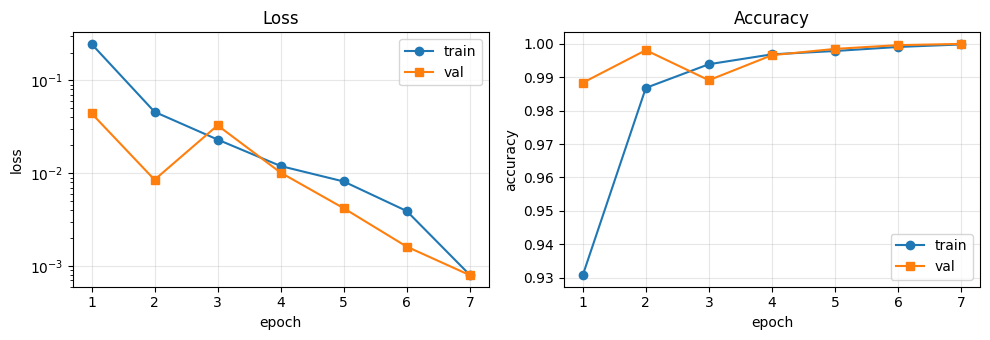

In [7]:
hist = ckpt.get("history")
if hist:
    epochs = [h["epoch"] for h in hist]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax1.plot(epochs, [h["train_loss"] for h in hist], "-o", label="train")
    ax1.plot(epochs, [h["val_loss"]   for h in hist], "-s", label="val")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.set_yscale("log")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, [h["train_acc"] for h in hist], "-o", label="train")
    ax2.plot(epochs, [h["val_acc"]   for h in hist], "-s", label="val")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("no history in checkpoint (older format)")

### Accuracy on held-out val and on the official test set


In [8]:
gtsrb_train_eval = GTSRB(root=DATA_DIR, split="train", transform=eval_tf)
gtsrb_test = GTSRB(root=DATA_DIR, split="test", transform=eval_tf)

@torch.no_grad()
def accuracy(loader):
    correct = total = 0
    for x, y in loader:
        x = x.to(DEVICE)
        correct += (model(x).argmax(1).cpu() == y).sum().item()
        total += y.size(0)
    return correct / total

# Val acc was recorded during training and stored in the checkpoint, no recompute needed.
modelval_acc = ckpt["val_acc"]

# Cache test accuracy: deterministic, so we only ever compute it once.
test_acc_path = os.path.join(CACHE_DIR, "gtsrb_test_acc.json")
if os.path.exists(test_acc_path):
    test_acc = json.load(open(test_acc_path))["test_acc"]
else:
    test_acc = accuracy(DataLoader(gtsrb_test, batch_size=128, num_workers=0))
    with open(test_acc_path, "w") as f:
        json.dump({"test_acc": test_acc}, f)

print(f"GTSRB model-val top-1 (random 10% of train, leaky): {modelval_acc:.4f}")
print(f"GTSRB official test  top-1 (different signs entirely): {test_acc:.4f}")

GTSRB model-val top-1 (random 10% of train, leaky): 1.0000
GTSRB official test  top-1 (different signs entirely): 0.9918


### Feature extraction

Hook all 19 MobileNetV2 blocks, pool the spatial maps (per-layer pool size
from `POOL_SIZES`), cache to `./cache/`.


In [9]:
class FeatureHooks:
    """Attach forward hooks; collect pooled features (B,C) per named layer.
    `pooling`: "avg" (default) or "softmax" (softmax-weighted spatial pooling)."""
    def __init__(self, model, layer_indices, pooling="avg"):
        self.layer_indices = layer_indices
        self.pooling = pooling
        self.features = {}
        self._handles = []
        for idx in layer_indices:
            name = f"block{idx}"
            self._handles.append(model.features[idx].register_forward_hook(self._hook(name)))
    def _hook(self, name):
        def fn(_, __, out):
            if out.dim() == 4:
                if self.pooling == "avg":
                    k = POOL_SIZES.get(name, 1)
                    if k <= 1:
                        out = out.mean(dim=(2, 3))                     # global avg pool
                    else:
                        out = F.adaptive_avg_pool2d(out, k).flatten(1) # spatial-grid avg pool
                elif self.pooling == "softmax":
                    B, C, H, W = out.shape
                    spatial = out.view(B, C, -1)                       # (B, C, H*W)
                    weights = F.softmax(spatial, dim=-1)
                    out = (spatial * weights).sum(dim=-1)              # (B, C)
                else:
                    raise ValueError(f"unknown pooling mode: {self.pooling}")
            self.features[name] = out
        return fn
    def remove(self):
        for h in self._handles: h.remove()

hooks = FeatureHooks(model, LAYERS, pooling=M_DISTANCE_POOLING)

def loader(ds, batch=128):
    return DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0)

@torch.no_grad()
def extract(ds, also_logits=False, labels_too=False):
    feats = {n: [] for n in LAYER_NAMES}
    logits, labels = [], []
    for batch in loader(ds):
        x, y = batch
        x = x.to(DEVICE)
        out = model(x)
        for n in LAYER_NAMES:
            feats[n].append(hooks.features[n].detach().cpu().numpy())
        if also_logits: logits.append(out.detach().cpu().numpy())
        if labels_too: labels.append(np.asarray(y))
    feats = {k: np.concatenate(v, 0) for k, v in feats.items()}
    out = {"features": feats}
    if also_logits: out["logits"] = np.concatenate(logits, 0)
    if labels_too:  out["labels"] = np.concatenate(labels, 0)
    return out

def extract_cached(name, ds, also_logits=False, labels_too=False):
    suffix = "" if M_DISTANCE_POOLING == "avg" else f"_{M_DISTANCE_POOLING}"
    path = os.path.join(CACHE_DIR, f"{name}{suffix}.npz")
    if os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        out = {"features": {k.replace("feat_", ""): d[k] for k in d.files if k.startswith("feat_")}}
        if "logits" in d.files: out["logits"] = d["logits"]
        if "labels" in d.files: out["labels"] = d["labels"]
        print(f"  load  {name}.npz")
        return out
    print(f"  extract {name} ({len(ds)} samples)", flush=True)
    t0 = time.time()
    out = extract(ds, also_logits=also_logits, labels_too=labels_too)
    save = {f"feat_{k}": v for k, v in out["features"].items()}
    if "logits" in out: save["logits"] = out["logits"]
    if "labels" in out: save["labels"] = out["labels"]
    np.savez_compressed(path, **save)
    print(f"  done in {time.time()-t0:.1f}s")
    return out

In [10]:
gtsrb_fit_ds = Subset(gtsrb_train_eval, train_idx)

rng = np.random.default_rng(1)
perm_id = rng.permutation(len(gtsrb_test))[:N_ID_VAL + N_ID_TEST]
id_val_ds = Subset(gtsrb_test, perm_id[:N_ID_VAL])
id_test_ds = Subset(gtsrb_test, perm_id[N_ID_VAL:])

print("extracting features ...")
fit_out = extract_cached("fit", gtsrb_fit_ds, labels_too=True)
id_test_out = extract_cached("id_test", id_test_ds, also_logits=True, labels_too=True)

print("\nlayer dims:")
for n in LAYER_NAMES:
    print(f"  {n}: dim={fit_out['features'][n].shape[1]}  "
          f"N_fit={fit_out['features'][n].shape[0]}")

extracting features ...
  load  fit.npz
  load  id_test.npz

layer dims:
  block0: dim=512  N_fit=23976
  block1: dim=256  N_fit=23976
  block2: dim=384  N_fit=23976
  block3: dim=384  N_fit=23976
  block4: dim=512  N_fit=23976
  block5: dim=512  N_fit=23976
  block6: dim=512  N_fit=23976
  block7: dim=256  N_fit=23976
  block8: dim=256  N_fit=23976
  block9: dim=256  N_fit=23976
  block10: dim=256  N_fit=23976
  block11: dim=384  N_fit=23976
  block12: dim=384  N_fit=23976
  block13: dim=384  N_fit=23976
  block14: dim=160  N_fit=23976
  block15: dim=160  N_fit=23976
  block16: dim=160  N_fit=23976
  block17: dim=320  N_fit=23976
  block18: dim=1280  N_fit=23976


### Per-class Gaussians (tied covariance)

Per-class mean plus one shared covariance, matching Eq. 1 of the report.


In [11]:
def fit_gaussian(feats, labels, num_classes, shrink=0.1):
    """Per-class means and a single tied covariance (Eq. 1 of the report)
    with Ledoit-Wolf-style shrinkage for numerical conditioning at high-D layers."""
    feats = np.asarray(feats, dtype=np.float64)
    D = feats.shape[1]
    means = np.zeros((num_classes, D))
    centered = []
    for c in range(num_classes):
        m = feats[labels == c]
        if len(m) == 0: continue
        mu = m.mean(axis=0); means[c] = mu
        centered.append(m - mu)
    centered = np.concatenate(centered, axis=0)
    cov = (centered.T @ centered) / centered.shape[0]
    target = (np.trace(cov) / D) * np.eye(D)
    cov = (1 - shrink) * cov + shrink * target
    return means.astype(np.float32), np.linalg.inv(cov).astype(np.float32)

gaussians = {}
fit_labels = fit_out["labels"]
for n in LAYER_NAMES:
    means, prec = fit_gaussian(fit_out["features"][n], fit_labels, NUM_CLASSES)
    gaussians[n] = (means, prec)
    print(f"  {n}: means {means.shape}  precision {prec.shape}")

  block0: means (43, 512)  precision (512, 512)
  block1: means (43, 256)  precision (256, 256)
  block2: means (43, 384)  precision (384, 384)
  block3: means (43, 384)  precision (384, 384)
  block4: means (43, 512)  precision (512, 512)
  block5: means (43, 512)  precision (512, 512)
  block6: means (43, 512)  precision (512, 512)
  block7: means (43, 256)  precision (256, 256)
  block8: means (43, 256)  precision (256, 256)
  block9: means (43, 256)  precision (256, 256)
  block10: means (43, 256)  precision (256, 256)
  block11: means (43, 384)  precision (384, 384)
  block12: means (43, 384)  precision (384, 384)
  block13: means (43, 384)  precision (384, 384)
  block14: means (43, 160)  precision (160, 160)
  block15: means (43, 160)  precision (160, 160)
  block16: means (43, 160)  precision (160, 160)
  block17: means (43, 320)  precision (320, 320)
  block18: means (43, 1280)  precision (1280, 1280)


## 3. Out-of-Domain Analysis

All OOD evaluations below share the same machinery: per-layer Mahalanobis
scoring against the fitted Gaussians, the same ID test split, the same
metrics. Helpers are defined once in the next cell; every OOD source
calls `analyze_ood_source(...)`. Adding a new source is one cell.

Mahalanobis score:

$$
\text{score}(x) \;=\; \min_{c}\; \bigl(f(x) - \hat{\mu}_c\bigr)^{\!\top}\, \hat{\Sigma}^{-1}\, \bigl(f(x) - \hat{\mu}_c\bigr)
$$

Lower means more in-distribution. Same as Lee et al. Eq. 2 (and Eq. 2 in
the report), with the outer minus sign dropped.


In [12]:
# --- Shared scoring helpers (used for every OOD source below) ---

EVAL_ID_NAME = "GTSRB"


def format_eval_context(id_name, ood_name):
    return f"ID = {id_name} | OOD = {ood_name}"


def add_eval_context(prefix, id_name, ood_name):
    return f"{prefix} | {format_eval_context(id_name, ood_name)}"


def mahalanobis_min(feats, means, precision):
    feats = np.asarray(feats, dtype=np.float64)
    means = np.asarray(means, dtype=np.float64)
    P = np.asarray(precision, dtype=np.float64)
    Px = feats @ P
    Pmu = means @ P
    quad_x = np.einsum("nd,nd->n", Px, feats)
    quad_mu = np.einsum("cd,cd->c", Pmu, means)
    cross = Px @ means.T
    return (quad_x[:, None] + quad_mu[None, :] - 2.0 * cross).min(axis=1)


def metric_set(scores_id, scores_ood, higher_is_more_id=True):
    s_id = -scores_id if higher_is_more_id else scores_id
    s_ood = -scores_ood if higher_is_more_id else scores_ood
    y = np.concatenate([np.zeros_like(s_id), np.ones_like(s_ood)])
    s = np.concatenate([s_id, s_ood])
    auroc = roc_auc_score(y, s)
    thr = np.quantile(s_id, 0.95)
    tnr95 = float((s_ood > thr).mean())
    grid = np.quantile(s, np.linspace(0, 1, 1001))
    best = 0.0
    for t in grid:
        best = max(best, 0.5 * ((s_ood >= t).mean() + (s_id < t).mean()))
    return {"auroc": float(auroc), "tnr@95": tnr95, "det_acc": float(best)}


def score_layer(n, feats):
    means, prec = gaussians[n]
    return mahalanobis_min(feats, means, prec)


class OODWrapper(Dataset):
    """Wrap any (image, label) dataset to return (image, 0). Optional subsampling."""
    def __init__(self, base, n=None, seed=0):
        if n is None or n >= len(base):
            self.idx = np.arange(len(base))
        else:
            rng = np.random.default_rng(seed)
            self.idx = rng.permutation(len(base))[:n]
        self.base = base
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        x, _ = self.base[int(self.idx[i])]
        return x, 0


def evaluate_ood_source(ood_ds, name, display_name=None, id_name=None):
    """Per-layer Mahalanobis metrics for any OOD dataset. Caches features under
    `cache/ood_test_{name}.npz`. Returns dict with per_layer, md_ood."""
    id_name = EVAL_ID_NAME if id_name is None else id_name
    ood_name = display_name or name
    ood_out = extract_cached(f"ood_test_{name}", ood_ds, also_logits=True)
    md_ood = {n: score_layer(n, ood_out["features"][n]) for n in LAYER_NAMES}
    per_layer_metrics = {n: metric_set(md_id_test[n], md_ood[n], higher_is_more_id=False)
                         for n in LAYER_NAMES}
    return {"per_layer": per_layer_metrics, "md_ood": md_ood, "id_name": id_name, "ood_name": ood_name}


def _print_per_layer_table(result):
    pl = result["per_layer"]
    id_name = result.get("id_name", EVAL_ID_NAME)
    ood_name = result.get("ood_name", "OOD")
    print(format_eval_context(id_name, ood_name))
    print(f"{'layer':10s}  {'AUROC':>7s}  {'TNR@95':>7s}  {'DetAcc':>7s}")
    for n in LAYER_NAMES:
        m = pl[n]
        print(f"{n:10s}  {m['auroc']:.4f}   {m['tnr@95']:.4f}   {m['det_acc']:.4f}")


def _plot_bar(result, display_name):
    pl = result["per_layer"]
    id_name = result.get("id_name", EVAL_ID_NAME)
    vals = [pl[n]["auroc"] for n in LAYER_NAMES]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.bar(LAYER_NAMES, vals, color="steelblue")
    ax.set_ylim(0.5, 1.005); ax.set_ylabel("AUROC")
    ax.set_title(add_eval_context("Mahalanobis AUROC per block", id_name, display_name))
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, 0.51, f"{v:.3f}", ha="center", va="bottom",
                fontsize=8.5, rotation=90, color="white", fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()


def _plot_roc(result, display_name):
    id_name = result.get("id_name", EVAL_ID_NAME)
    colors = plt.cm.tab20(np.linspace(0, 1, len(LAYER_NAMES)))
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for n, color in zip(LAYER_NAMES, colors):
        sid = md_id_test[n]; sood = result["md_ood"][n]
        y = np.r_[np.zeros(len(sid)), np.ones(len(sood))]
        s = np.r_[sid, sood]                                  # higher distance = more OOD-like
        fpr, tpr, _ = roc_curve(y, s)
        ax.plot(fpr, tpr, color=color, lw=1.3, label=n)
    ax.plot([0, 1], [0, 1], "k--", lw=0.5)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(add_eval_context("ROC curves per block", id_name, display_name))
    ax.legend(loc="lower right", ncol=2, fontsize=7)
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def _plot_score_distribution(result, display_name, n_top=4):
    """Score-distribution histograms at the top n_top layers (sorted by AUROC desc)."""
    pl = result["per_layer"]
    top = sorted(LAYER_NAMES, key=lambda n: pl[n]["auroc"], reverse=True)[:n_top]
    id_name = result.get("id_name", EVAL_ID_NAME)
    ncols = 2
    nrows = (n_top + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.0 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, bl in zip(axes, top):
        sid = md_id_test[bl]; sood = result["md_ood"][bl]
        lo, hi = float(min(sid.min(), sood.min())), float(max(sid.max(), sood.max()))
        bins = np.linspace(lo, hi, 60)
        ax.hist(sid, bins=bins, alpha=0.6, color="steelblue", label=f"ID, n={len(sid)}")
        ax.hist(sood, bins=bins, alpha=0.6, color="darkorange", label=f"OOD, n={len(sood)}")
        ax.set_xlabel(f"Mahalanobis distance at {bl}")
        ax.set_ylabel("count")
        ax.set_title(f"{bl}  AUROC={pl[bl]['auroc']:.4f}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    for ax in axes[len(top):]:
        ax.axis("off")
    fig.suptitle(add_eval_context(f"Score distributions at top {n_top} layers", id_name, display_name))
    plt.tight_layout(); plt.show()


def analyze_ood_source(ood_ds, name, display_name=None, id_name=None):
    """End-to-end per-layer OOD analysis: scoring + table + bar + ROC + histogram.
    Returns the result dict (per_layer, md_ood)."""
    id_name = EVAL_ID_NAME if id_name is None else id_name
    display_name = display_name or name
    result = evaluate_ood_source(ood_ds, name, display_name=display_name, id_name=id_name)
    _print_per_layer_table(result)
    _plot_bar(result, display_name)
    _plot_roc(result, display_name)
    _plot_score_distribution(result, display_name)
    return result


# Reference ID scores, computed once and reused by every OOD evaluation
md_id_test = {n: score_layer(n, id_test_out["features"][n]) for n in LAYER_NAMES}

### Multi-layer combination

Each block in MobileNetV2 produces its own Mahalanobis score for an image. The single-layer analysis above picks one block and ignores the rest. Here we try the opposite: collapse the per-block scores into one number per image and ask whether that beats the best individual block.

The blocks disagree on scale (`block18` distances are ~1000x `block0`'s), so before combining we z-score each block using the clean-ID distribution at that block. After z-scoring, 0 means "typical for ID", positive means "further than typical". Three combiners:

- `mean_z` -- average the z-scored per-block distances. Unsupervised, every block weighted equally.
- `uniform_sum` -- sum instead of mean (same ranking, kept as a sanity check).
- `logreg_fgsm` -- the paper's recipe. Fit a logistic regression to tell clean ID images apart from FGSM-perturbed copies of those same ID images, using the per-block distances as features. The regression learns a weight per block; useless blocks get a weight near zero. No OOD data is used anywhere -- FGSM gives us a stand-in for "weird inputs" generated from ID alone.

Layer presets passed to the combiners:

- `LAYER_NAMES` -- all 19 blocks.
- `STAGE_LAYERS` -- the 5 MobileNetV2 stage boundaries (`block1, 3, 6, 13, 18`); analogous to "one feature per ResNet stage" in the paper.

Unweighted averages get hurt by uninformative blocks, so `mean_z` uses the smaller stage subset. `logreg_fgsm` learns its own weights, so it gets all 19.

In [ ]:
# --- Multi-layer combiners + FGSM tuning (no OOD data is used to fit or tune) ---
from sklearn.linear_model import LogisticRegression

STAGE_LAYERS = ["block1", "block3", "block6", "block13", "block18"]   # MobileNetV2 stage outputs


def _stack_md(md_dict, layers):
    return np.stack([md_dict[n] for n in layers], axis=1)              # (N, L)


def id_layer_stats(md_id, layers):
    M = _stack_md(md_id, layers)
    return M.mean(axis=0), M.std(axis=0) + 1e-12


def combine_mean_z(md_eval, layers, id_stats):
    mu, sd = id_stats
    return ((_stack_md(md_eval, layers) - mu) / sd).mean(axis=1)


def combine_uniform_sum(md_eval, layers, id_stats):
    mu, sd = id_stats
    return ((_stack_md(md_eval, layers) - mu) / sd).sum(axis=1)


def combine_logreg(md_eval, layers, lr):
    return lr.decision_function(_stack_md(md_eval, layers))            # higher = more OOD-like


def fgsm_md(ds, tag, eps, batch=64):
    """Score every LAYER_NAMES on clean and FGSM-perturbed copies of `ds`.
    Caches MD scores (not features) under cache/fgsm_{tag}_eps{eps}.npz."""
    suffix = "" if M_DISTANCE_POOLING == "avg" else f"_{M_DISTANCE_POOLING}"
    path = os.path.join(CACHE_DIR, f"fgsm_{tag}{suffix}_eps{eps:.4f}.npz")
    if os.path.exists(path):
        d = np.load(path)
        md_clean = {n: d[f"clean_{n}"] for n in LAYER_NAMES}
        md_adv = {n: d[f"adv_{n}"]   for n in LAYER_NAMES}
        print(f"  load  fgsm_{tag}.npz")
        return md_clean, md_adv
    print(f"  FGSM tune  tag={tag}  eps={eps}  n={len(ds)}", flush=True)
    model.eval()
    clean_feats = {n: [] for n in LAYER_NAMES}
    adv_feats = {n: [] for n in LAYER_NAMES}
    for x, y in DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0):
        x = x.to(DEVICE); y = y.to(DEVICE)
        with torch.no_grad():
            _ = model(x)
            for n in LAYER_NAMES:
                clean_feats[n].append(hooks.features[n].detach().cpu().numpy())
        x_adv = x.clone().detach().requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = (x_adv + eps * grad.sign()).detach()
        with torch.no_grad():
            _ = model(x_adv)
            for n in LAYER_NAMES:
                adv_feats[n].append(hooks.features[n].detach().cpu().numpy())
    clean_feats = {n: np.concatenate(v, 0) for n, v in clean_feats.items()}
    adv_feats = {n: np.concatenate(v, 0) for n, v in adv_feats.items()}
    md_clean = {n: score_layer(n, clean_feats[n]) for n in LAYER_NAMES}
    md_adv = {n: score_layer(n, adv_feats[n])   for n in LAYER_NAMES}
    save = {}
    for n in LAYER_NAMES:
        save[f"clean_{n}"] = md_clean[n]; save[f"adv_{n}"] = md_adv[n]
    np.savez_compressed(path, **save)
    return md_clean, md_adv


def fit_logreg_fgsm(md_clean, md_adv, layers):
    X = np.vstack([_stack_md(md_clean, layers), _stack_md(md_adv, layers)])
    y = np.r_[np.zeros(len(md_clean[layers[0]])), np.ones(len(md_adv[layers[0]]))]
    return LogisticRegression(C=1.0, max_iter=2000).fit(X, y)


def _print_combined_table(rows, display_name, id_name):
    print(f"\n{format_eval_context(id_name, display_name)}")
    print(f"{'method':28s}  {'AUROC':>7s}  {'TNR@95':>7s}  {'DetAcc':>7s}")
    for label, a, t, d in rows:
        print(f"{label:28s}  {a:.4f}   {t:.4f}   {d:.4f}")


def _plot_combined_bar(rows, display_name, id_name):
    labels = [r[0] for r in rows]
    vals = [r[1] for r in rows]
    fig, ax = plt.subplots(figsize=(9, 3.8))
    colors = ["dimgray"] + ["steelblue"] * (len(rows) - 1)
    ax.bar(labels, vals, color=colors)
    ax.set_ylim(0.5, 1.005); ax.set_ylabel("AUROC")
    ax.set_title(add_eval_context("AUROC by method", id_name, display_name))
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, 0.51, f"{v:.3f}", ha="center", va="bottom",
                fontsize=8.5, rotation=90, color="white", fontweight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.show()


def _plot_combined_roc(rows_scores, display_name, id_name):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    colors = ["dimgray"] + list(plt.cm.tab10(np.linspace(0, 1, max(1, len(rows_scores) - 1))))
    for (label, sid, sood, auroc), c in zip(rows_scores, colors):
        y = np.r_[np.zeros(len(sid)), np.ones(len(sood))]
        fpr, tpr, _ = roc_curve(y, np.r_[sid, sood])
        ax.plot(fpr, tpr, color=c, lw=1.4, label=f"{label}  AUROC={auroc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.5)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(add_eval_context("ROC: single vs multi-layer", id_name, display_name))
    ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def _plot_combined_score_distribution(rows_scores, display_name, id_name):
    n = len(rows_scores)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.0 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, (label, sid, sood, auroc) in zip(axes, rows_scores):
        lo, hi = float(min(sid.min(), sood.min())), float(max(sid.max(), sood.max()))
        bins = np.linspace(lo, hi, 60)
        ax.hist(sid, bins=bins, alpha=0.6, color="steelblue", label=f"ID, n={len(sid)}")
        ax.hist(sood, bins=bins, alpha=0.6, color="darkorange", label=f"OOD, n={len(sood)}")
        ax.set_xlabel("score (higher = more OOD-like)")
        ax.set_ylabel("count")
        ax.set_title(f"{label}  AUROC={auroc:.4f}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(add_eval_context("Score distributions per method", id_name, display_name))
    plt.tight_layout(); plt.show()

def _plot_logreg_weights(lr, layers, display_name, id_name):
    weights = lr.coef_[0]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    colors = ["tomato" if w < 0 else "steelblue" for w in weights]
    ax.bar(layers, weights, color=colors)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("logreg weight")
    ax.set_title(add_eval_context("logreg_fgsm block weights", id_name, display_name))
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def analyze_combined(ood_result, display_name, tag, eps=0.005, custom_layers=None):
    """Compare best single layer against multi-layer combinations on `ood_result`.
    `tag` namespaces the FGSM cache; pass e.g. "full" or "kept". `custom_layers` is
    an optional list of layer names (e.g. top-K by single-layer AUROC) -- when given,
    mean_z and logreg_fgsm are also evaluated on that subset. Reads module-scope
    `model`, `hooks`, `gaussians`, `md_id_test`, `id_val_ds`."""
    md_clean, md_adv = fgsm_md(id_val_ds, tag=tag, eps=eps)
    stats_stage = id_layer_stats(md_clean, STAGE_LAYERS)
    stats_all = id_layer_stats(md_clean, LAYER_NAMES)
    lr_all = fit_logreg_fgsm(md_clean, md_adv, LAYER_NAMES)

    id_name = ood_result.get("id_name", EVAL_ID_NAME)
    pl = ood_result["per_layer"]; md_ood = ood_result["md_ood"]
    best = max(LAYER_NAMES, key=lambda n: pl[n]["auroc"])

    presets = [
        ("mean_z (stage)", lambda m: combine_mean_z(m, STAGE_LAYERS, stats_stage)),
        ("mean_z (all)", lambda m: combine_mean_z(m, LAYER_NAMES, stats_all)),
        ("uniform_sum (stage)", lambda m: combine_uniform_sum(m, STAGE_LAYERS, stats_stage)),
        ("logreg_fgsm (all)", lambda m: combine_logreg(m, LAYER_NAMES, lr_all)),
    ]
    if custom_layers:
        cl = list(custom_layers)
        stats_cl = id_layer_stats(md_clean, cl)
        lr_cl = fit_logreg_fgsm(md_clean, md_adv, cl)
        presets += [
            (f"mean_z (custom, {len(cl)})", lambda m, cl=cl, s=stats_cl: combine_mean_z(m, cl, s)),
            (f"logreg_fgsm (custom, {len(cl)})", lambda m, cl=cl, lr=lr_cl:  combine_logreg(m, cl, lr)),
        ]
    rows = [(f"best single ({best})",
             pl[best]["auroc"], pl[best]["tnr@95"], pl[best]["det_acc"])]
    rows_scores = [(f"best single ({best})", md_id_test[best], md_ood[best], pl[best]["auroc"])]
    for label, fn in presets:
        sid = fn(md_id_test); sood = fn(md_ood)
        m = metric_set(sid, sood, higher_is_more_id=False)
        rows.append((label, m["auroc"], m["tnr@95"], m["det_acc"]))
        rows_scores.append((label, sid, sood, m["auroc"]))
    _print_combined_table(rows, display_name, id_name)
    _plot_combined_bar(rows, display_name, id_name)
    _plot_combined_roc(rows_scores, display_name, id_name)
    _plot_combined_score_distribution(rows_scores, display_name, id_name)
    _plot_logreg_weights(lr_all, LAYER_NAMES, display_name, id_name)
    if custom_layers:
        _plot_logreg_weights(lr_cl, cl, display_name, id_name)

    return {"rows": rows, "scores": rows_scores, "id_name": id_name, "ood_name": display_name}


### Tiny-ImageNet

Tiny-ImageNet: 5000 images
  load  ood_test_tiny_imagenet.npz
ID = GTSRB | OOD = Tiny-ImageNet
layer         AUROC   TNR@95   DetAcc
block0      0.9038   0.5320   0.8176
block1      0.9356   0.6620   0.8612
block2      0.9875   0.9678   0.9590
block3      0.9913   0.9840   0.9686
block4      0.9946   0.9906   0.9736
block5      0.9957   0.9926   0.9758
block6      0.9965   0.9946   0.9784
block7      0.9965   0.9960   0.9784
block8      0.9972   0.9972   0.9816
block9      0.9974   0.9974   0.9818
block10     0.9977   0.9982   0.9836
block11     0.9985   0.9988   0.9870
block12     0.9984   0.9980   0.9864
block13     0.9978   0.9972   0.9836
block14     0.9971   0.9946   0.9774
block15     0.9984   0.9984   0.9826
block16     0.9985   0.9990   0.9846
block17     0.9903   0.9990   0.9784
block18     0.9637   0.9058   0.9630


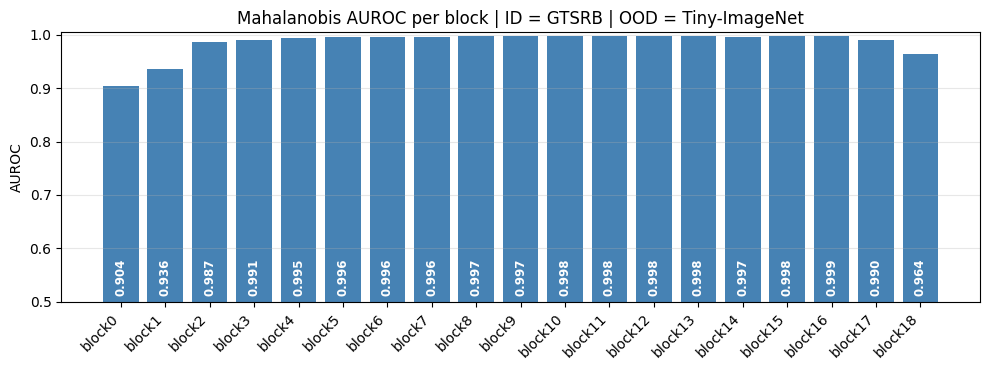

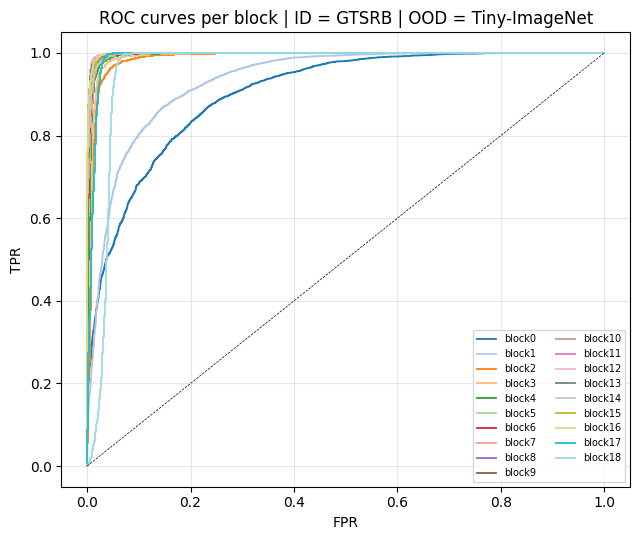

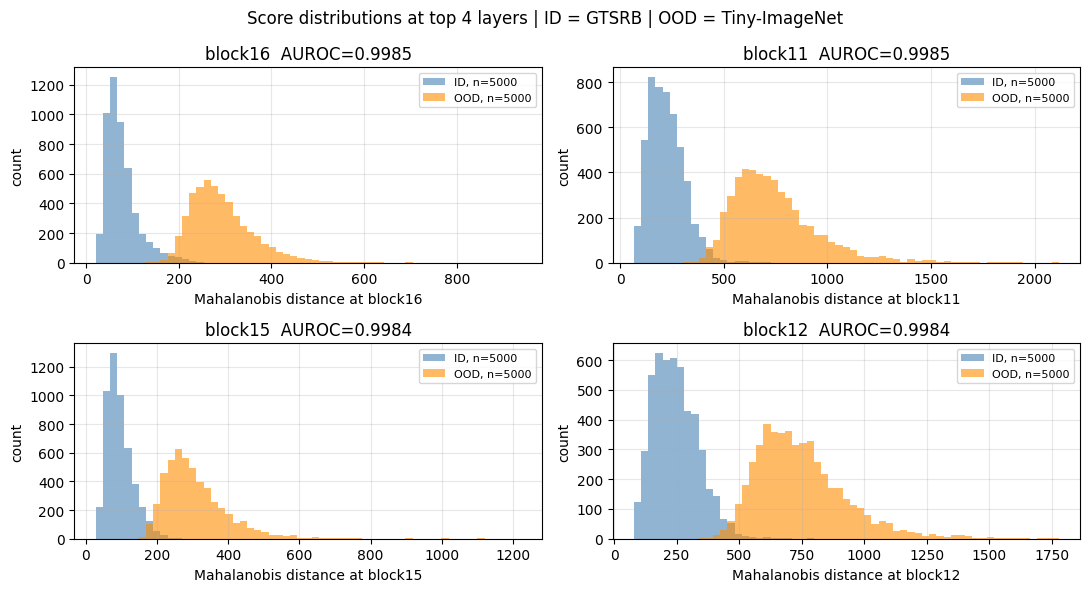

In [14]:
class TinyImageNetFlat(Dataset):
    """Flat reader for Tiny-ImageNet's `train/<wnid>/images/*.JPEG` layout.
    Optional `exclude_wnids` drops semantically in-domain classes (e.g. cat/dog breeds)."""
    def __init__(self, root, transform, exclude_wnids=None):
        exclude_wnids = set(exclude_wnids or [])
        paths = []
        for wnid in sorted(os.listdir(root)):
            if wnid in exclude_wnids:
                continue
            d = os.path.join(root, wnid, "images")
            if not os.path.isdir(d): continue
            for f in sorted(os.listdir(d)):
                if f.lower().endswith(".jpeg"):
                    paths.append(os.path.join(d, f))
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert("RGB")), 0


def download_tiny_imagenet():
    target = os.path.join(DATA_DIR, "tiny-imagenet-200")
    if os.path.isdir(target):
        return target
    zip_path = os.path.join(DATA_DIR, "tiny-imagenet-200.zip")
    if not os.path.exists(zip_path):
        url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
        print(f"downloading {url} ...")
        urllib.request.urlretrieve(url, zip_path)
    print("unzipping ...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)
    return target


tin_base = TinyImageNetFlat(os.path.join(download_tiny_imagenet(), "train"), transform=eval_tf)
tin_ds = OODWrapper(tin_base, n=N_OOD_TEST, seed=0)
print(f"Tiny-ImageNet: {len(tin_ds)} images")

tin_result = analyze_ood_source(tin_ds, "tiny_imagenet", "Tiny-ImageNet")

  load  fgsm_full.npz

ID = GTSRB | OOD = Tiny-ImageNet
method                          AUROC   TNR@95   DetAcc
best single (block16)         0.9985   0.9990   0.9846
mean_z (stage)                0.9962   0.9978   0.9820
mean_z (all)                  0.9990   0.9998   0.9900
uniform_sum (stage)           0.9962   0.9978   0.9820
logreg_fgsm (all)             0.9456   0.7962   0.8990


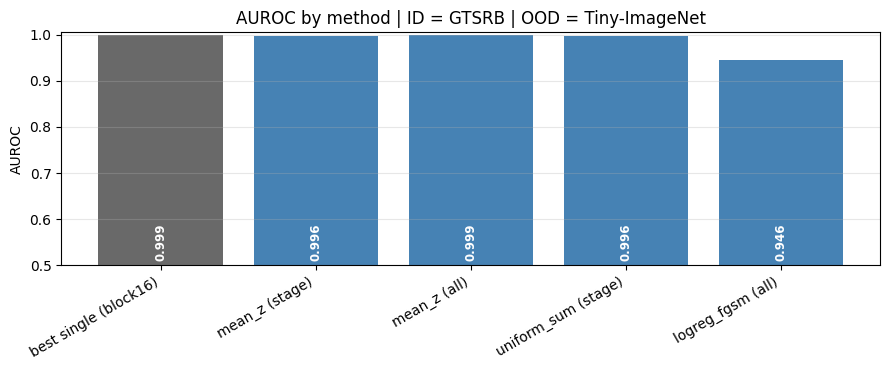

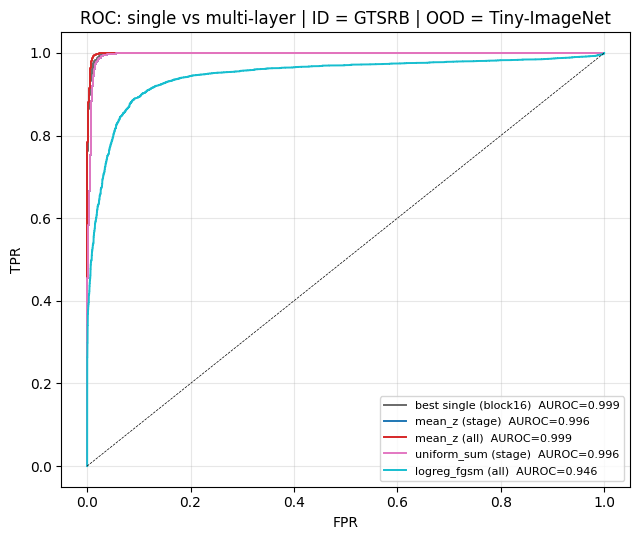

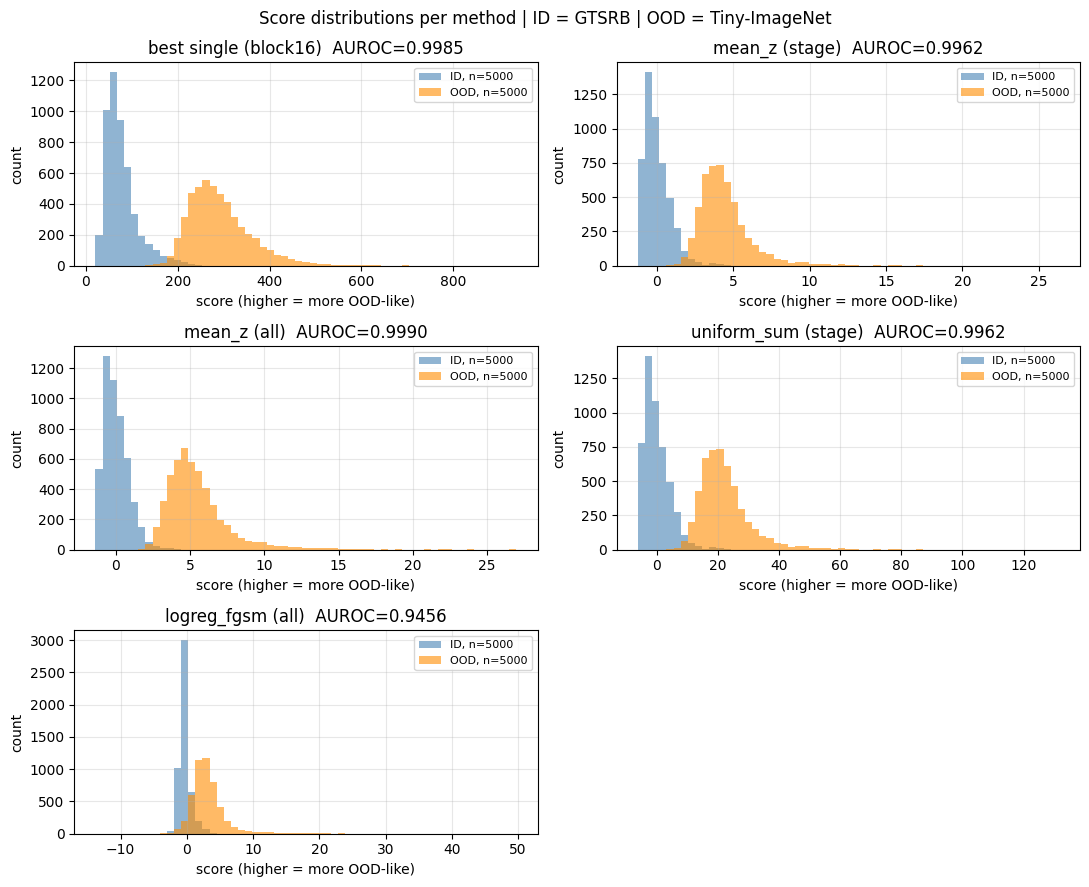

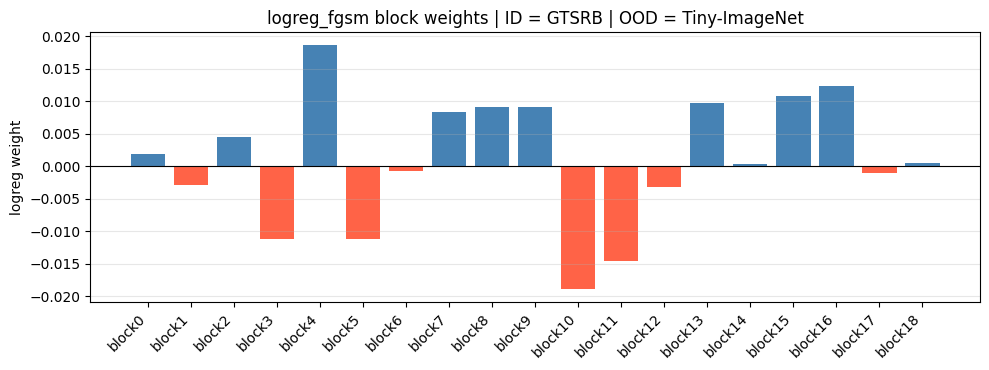

{'rows': [('best single (block16)', 0.9985250000000001, 0.999, 0.9846),
  ('mean_z (stage)', 0.99623676, 0.9978, 0.982),
  ('mean_z (all)', 0.99904256, 0.9998, 0.99),
  ('uniform_sum (stage)', 0.99623676, 0.9978, 0.982),
  ('logreg_fgsm (all)', 0.9456284399999999, 0.7962, 0.899)],
 'scores': [('best single (block16)',
   array([51.37726166, 42.67202387, 64.8610844 , ..., 85.11589615,
          76.9033214 , 83.92962917]),
   array([217.99755778, 299.20724537, 265.5782935 , ..., 247.07578   ,
          400.96239979, 373.1346649 ]),
   0.9985250000000001),
  ('mean_z (stage)',
   array([-0.31127619, -0.6308737 ,  0.20773006, ...,  0.34113543,
          -0.21645525,  0.42170255]),
   array([3.76273168, 4.15916805, 3.41898125, ..., 2.68283645, 4.47858472,
          4.46810814]),
   0.99623676),
  ('mean_z (all)',
   array([-0.28967062, -0.67840763,  0.26872328, ...,  0.24202693,
          -0.20622711,  0.28190481]),
   array([4.10661475, 5.44488379, 3.93611055, ..., 3.18698731, 6.46779003,


In [15]:
analyze_combined(tin_result, "Tiny-ImageNet", tag="full")

  load  fgsm_full.npz

ID = GTSRB | OOD = Tiny-ImageNet
method                          AUROC   TNR@95   DetAcc
best single (block16)         0.9985   0.9990   0.9846
mean_z (stage)                0.9962   0.9978   0.9820
mean_z (all)                  0.9990   0.9998   0.9900
uniform_sum (stage)           0.9962   0.9978   0.9820
logreg_fgsm (all)             0.9456   0.7962   0.8990
mean_z (custom, 5)            0.9996   1.0000   0.9938
logreg_fgsm (custom, 5)       0.9360   0.7558   0.8898


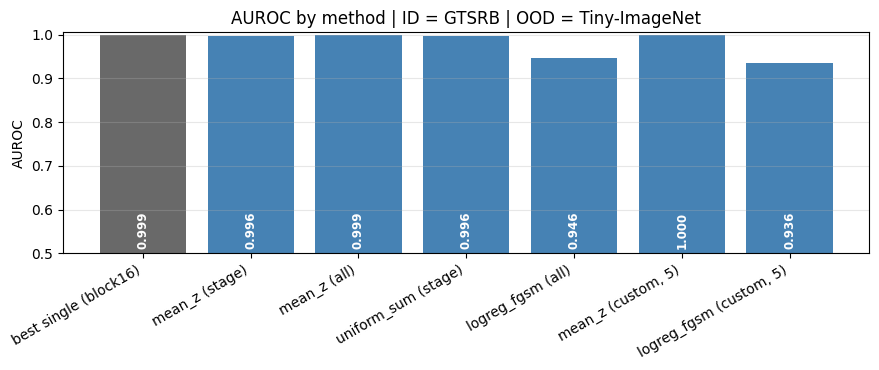

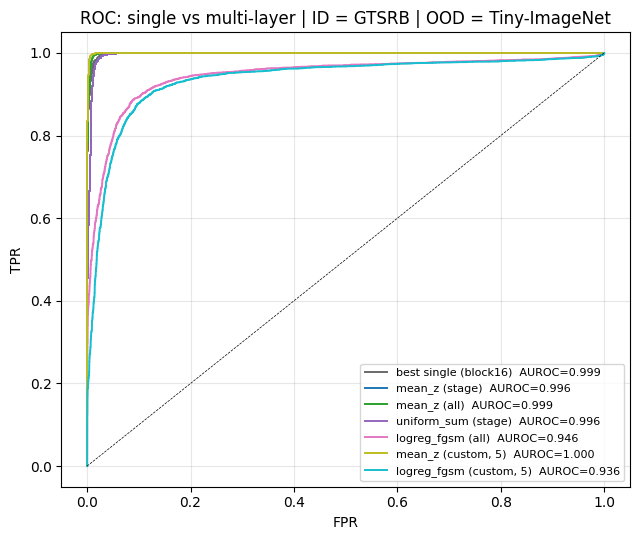

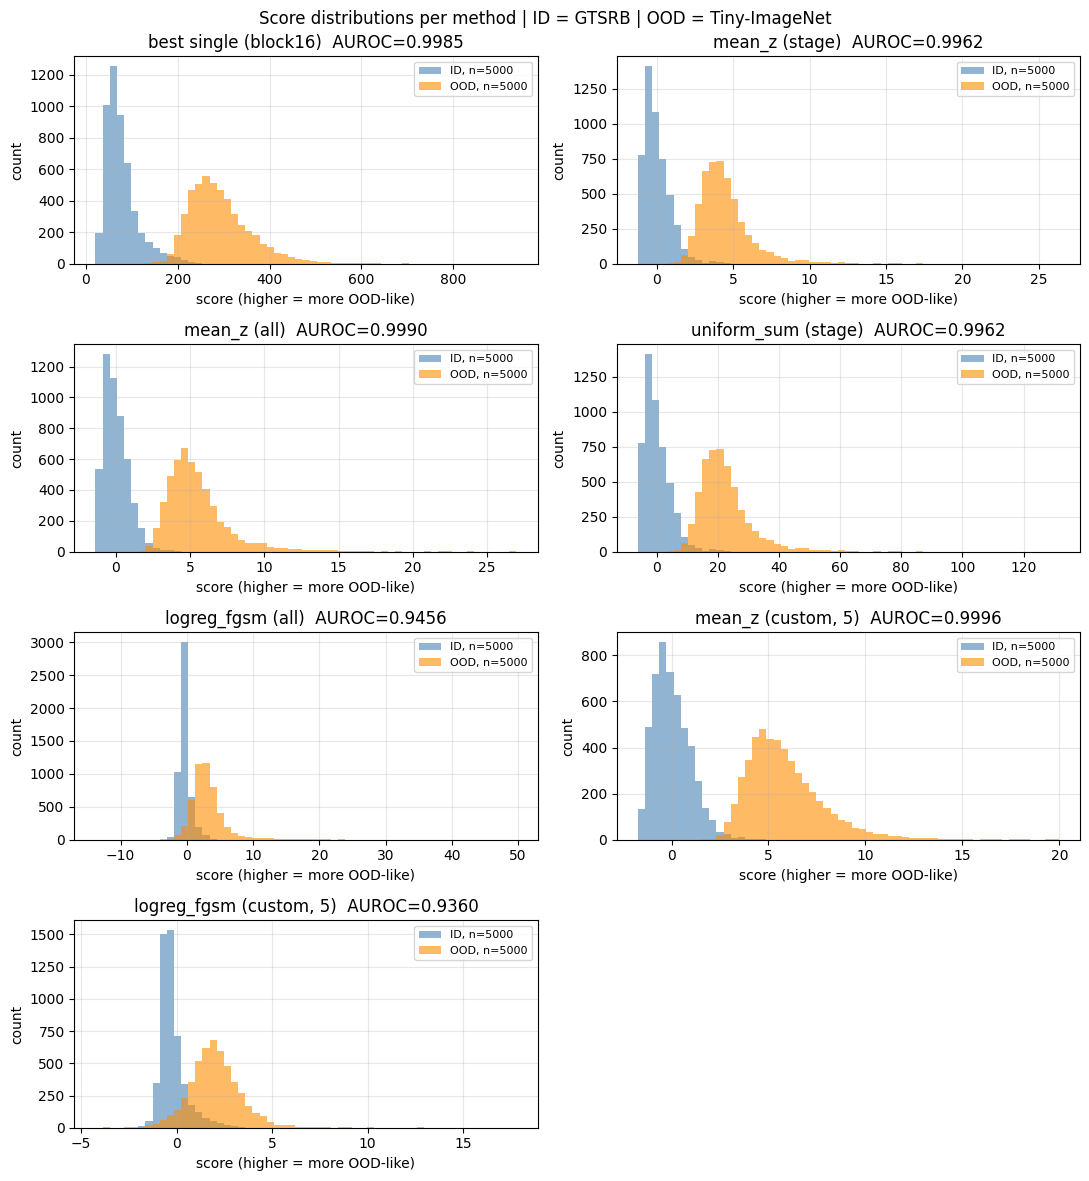

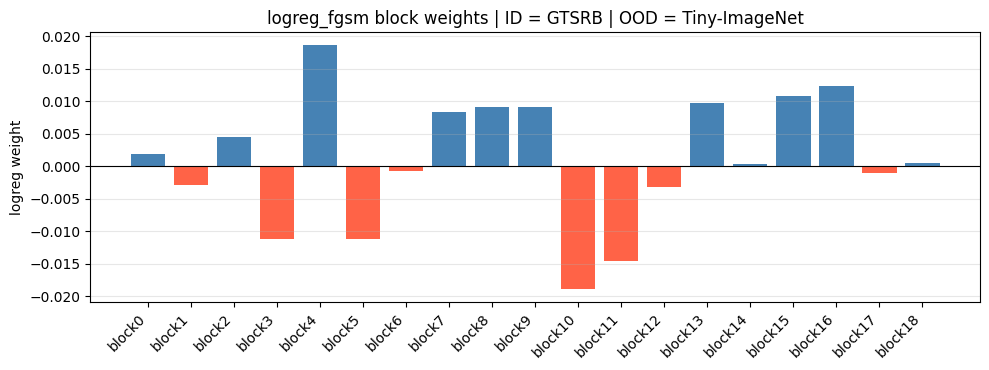

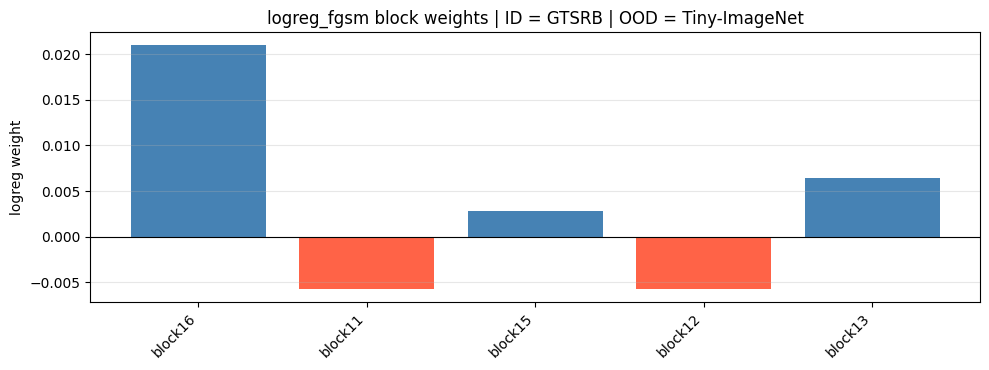

{'rows': [('best single (block16)', 0.9985250000000001, 0.999, 0.9846),
  ('mean_z (stage)', 0.99623676, 0.9978, 0.982),
  ('mean_z (all)', 0.99904256, 0.9998, 0.99),
  ('uniform_sum (stage)', 0.99623676, 0.9978, 0.982),
  ('logreg_fgsm (all)', 0.9456284399999999, 0.7962, 0.899),
  ('mean_z (custom, 5)', 0.99960216, 1.0, 0.9938),
  ('logreg_fgsm (custom, 5)', 0.93603744, 0.7558, 0.8898)],
 'scores': [('best single (block16)',
   array([51.37726166, 42.67202387, 64.8610844 , ..., 85.11589615,
          76.9033214 , 83.92962917]),
   array([217.99755778, 299.20724537, 265.5782935 , ..., 247.07578   ,
          400.96239979, 373.1346649 ]),
   0.9985250000000001),
  ('mean_z (stage)',
   array([-0.31127619, -0.6308737 ,  0.20773006, ...,  0.34113543,
          -0.21645525,  0.42170255]),
   array([3.76273168, 4.15916805, 3.41898125, ..., 2.68283645, 4.47858472,
          4.46810814]),
   0.99623676),
  ('mean_z (all)',
   array([-0.28967062, -0.67840763,  0.26872328, ...,  0.24202693,
   

In [16]:
top5 = sorted(LAYER_NAMES, key=lambda n: tin_result["per_layer"][n]["auroc"], reverse=True)[:5]
analyze_combined(tin_result, "Tiny-ImageNet", tag="full", custom_layers=top5)

### Oxford-IIIT Pet

Oxford Pets: 3680 images
  load  ood_test_oxford_pets.npz
ID = GTSRB | OOD = Oxford Pets
layer         AUROC   TNR@95   DetAcc
block0      0.9060   0.4796   0.8290
block1      0.9733   0.8552   0.9177
block2      0.9996   0.9997   0.9918
block3      0.9994   0.9997   0.9910
block4      0.9995   0.9997   0.9915
block5      0.9991   0.9997   0.9899
block6      0.9990   0.9995   0.9897
block7      0.9988   0.9997   0.9880
block8      0.9989   0.9997   0.9880
block9      0.9988   0.9997   0.9880
block10     0.9986   0.9992   0.9869
block11     0.9986   0.9997   0.9904
block12     0.9983   0.9997   0.9875
block13     0.9974   0.9984   0.9831
block14     0.9956   0.9957   0.9762
block15     0.9976   0.9976   0.9809
block16     0.9983   1.0000   0.9855
block17     0.9852   0.9986   0.9765
block18     0.9610   0.8628   0.9631


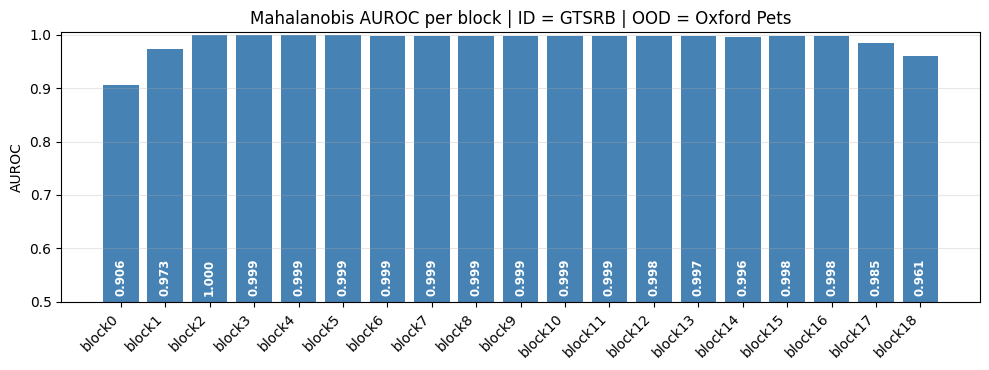

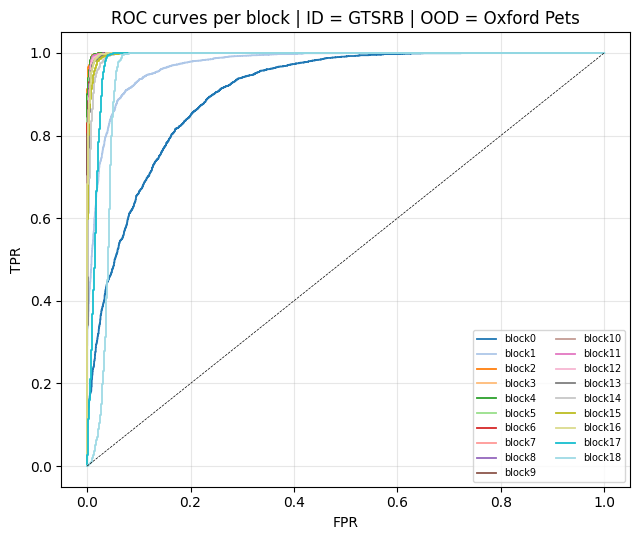

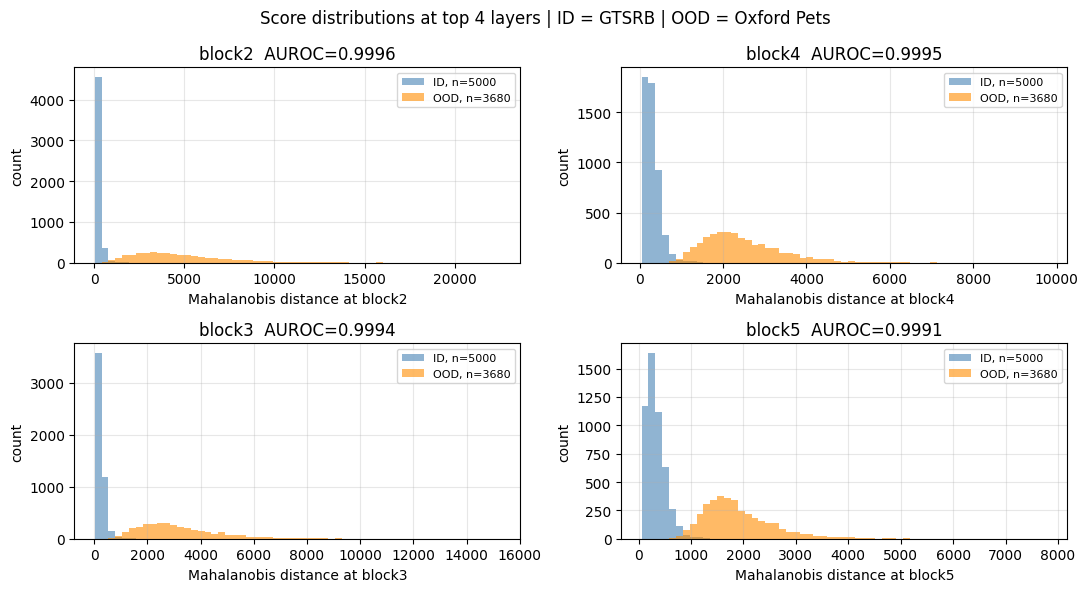

In [17]:
from torchvision.datasets import OxfordIIITPet

pets_base = OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category",
                          transform=eval_tf, download=True)
pets_ds = OODWrapper(pets_base, n=N_OOD_TEST, seed=0)
print(f"Oxford Pets: {len(pets_ds)} images")

pets_result = analyze_ood_source(pets_ds, "oxford_pets", "Oxford Pets")

  load  fgsm_full.npz

ID = GTSRB | OOD = Oxford Pets
method                          AUROC   TNR@95   DetAcc
best single (block2)          0.9996   0.9997   0.9918
mean_z (stage)                0.9993   0.9997   0.9909
mean_z (all)                  0.9998   1.0000   0.9948
uniform_sum (stage)           0.9993   0.9997   0.9909
logreg_fgsm (all)             0.9983   0.9959   0.9887


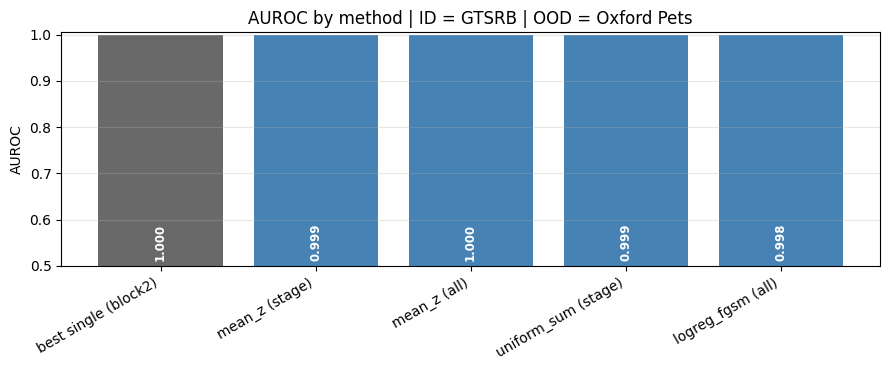

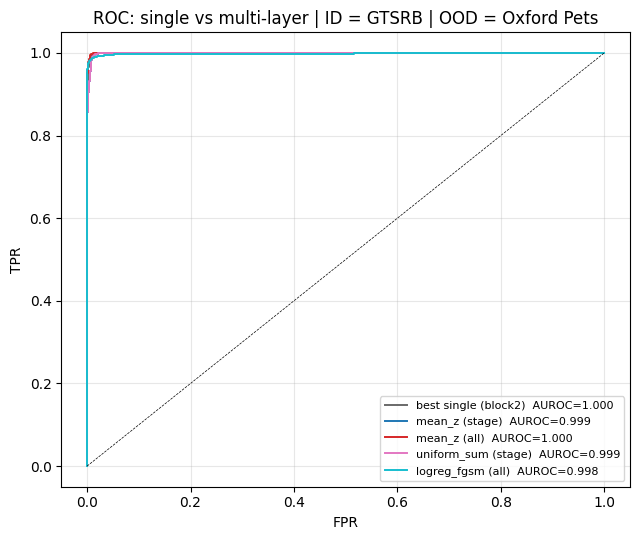

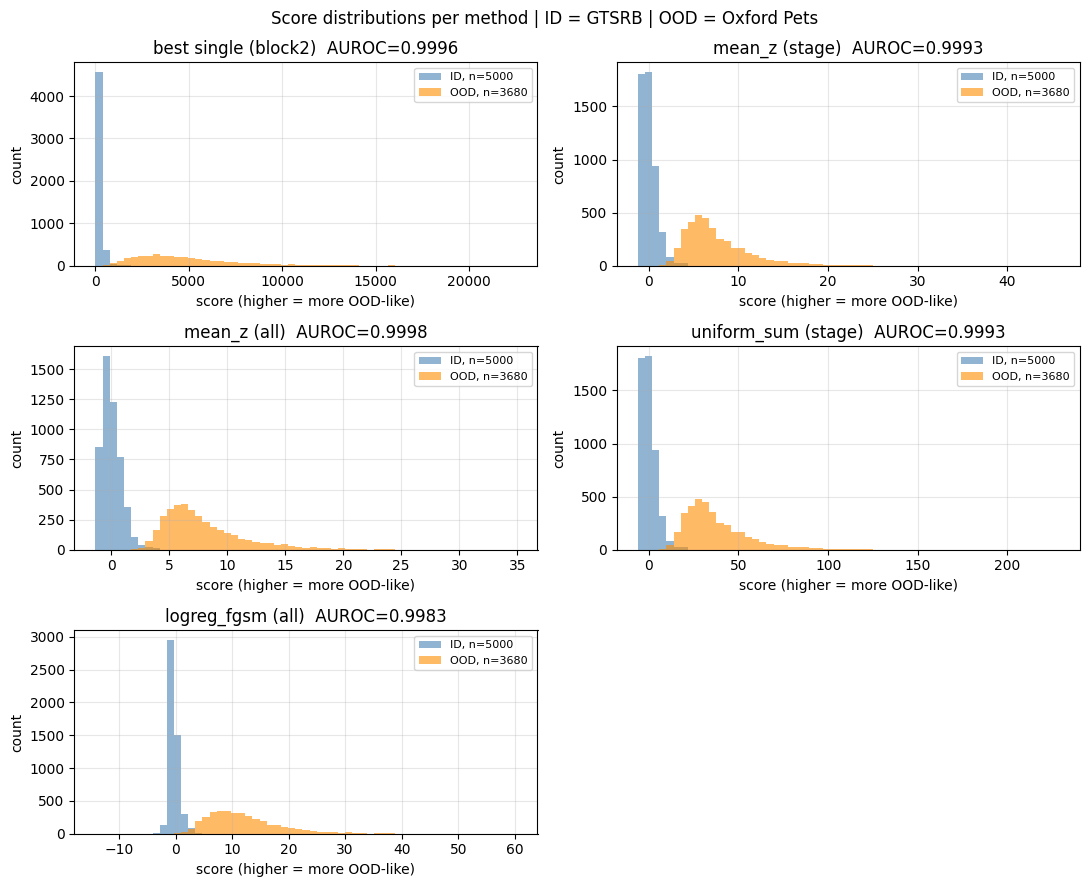

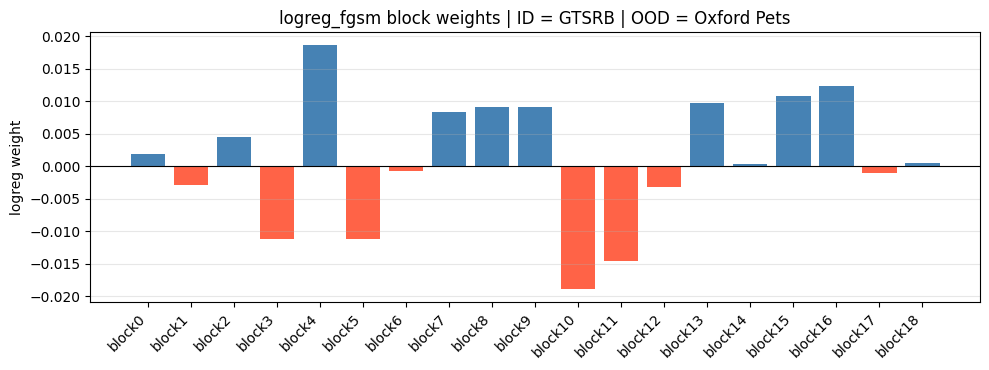

{'rows': [('best single (block2)',
   0.9995963586956522,
   0.9997282608695652,
   0.9918260869565217),
  ('mean_z (stage)',
   0.9992579347826086,
   0.9997282608695652,
   0.9908771739130435),
  ('mean_z (all)', 0.9998191847826087, 1.0, 0.9948489130434783),
  ('uniform_sum (stage)',
   0.9992579347826086,
   0.9997282608695652,
   0.9908771739130435),
  ('logreg_fgsm (all)',
   0.9983391847826086,
   0.9959239130434783,
   0.9887271739130434)],
 'scores': [('best single (block2)',
   array([176.4498084 ,  85.70981399, 249.55017052, ..., 227.14200106,
          130.03514165, 225.86402898]),
   array([5070.31948093, 7751.24040679, 8973.53539998, ..., 8099.67217157,
          5388.73313405, 7012.31494726]),
   0.9995963586956522),
  ('mean_z (stage)',
   array([-0.31127619, -0.6308737 ,  0.20773006, ...,  0.34113543,
          -0.21645525,  0.42170255]),
   array([ 8.88652472, 17.23648974, 10.16907639, ..., 10.96906688,
           7.44688069,  8.59484286]),
   0.9992579347826086),
  ('

In [18]:
analyze_combined(pets_result, "Oxford Pets", tag="full")

## 4. Near-OOD: held-out GTSRB classes

The Tiny-ImageNet and Oxford-Pets results above are saturated (AUROC > 0.99 at most layers).

For a more challenging benchmark we construct a *near-OOD* split: retrain MobileNetV2 on a subset of the 43 GTSRB classes, then treat the held-out classes as OOD.

### 4.1 Class inventory

Before picking holdouts we look at sample counts and visual structure across the 43 GTSRB classes. The split needs to satisfy two constraints:

1. Held-out classes must have enough samples for a useful OOD test pool.
2. Held-out classes must not be visually idiosyncratic --> if the only octagonal sign is held out, the detector exploits shape alone and the benchmark re-saturates.

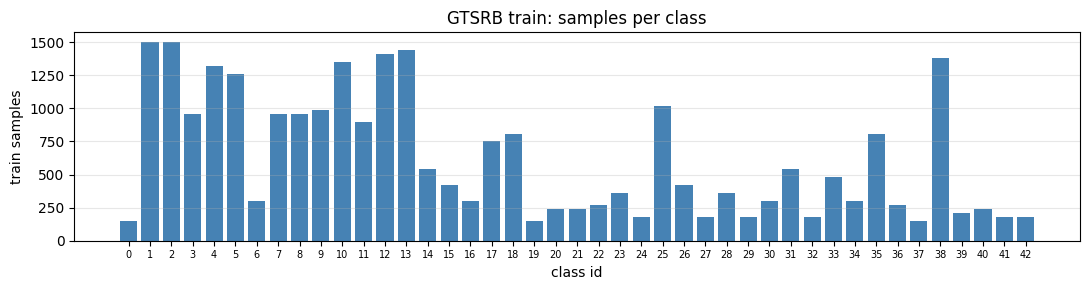

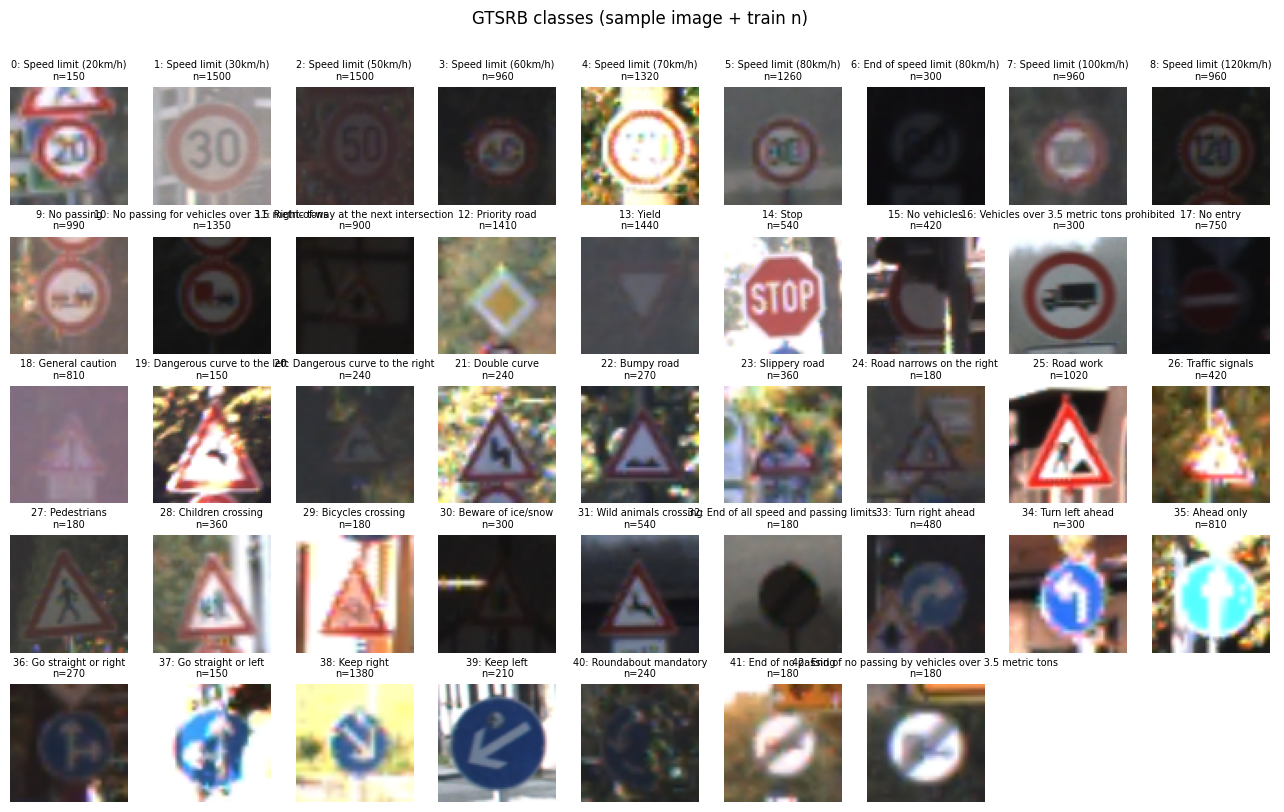

In [19]:
SIGNNAMES_URL = "https://raw.githubusercontent.com/udacity/CarND-Traffic-Sign-Classifier-Project/master/signnames.csv"
SIGNNAMES_PATH = os.path.join(DATA_DIR, "gtsrb_signnames.csv")
if not os.path.exists(SIGNNAMES_PATH):
    urllib.request.urlretrieve(SIGNNAMES_URL, SIGNNAMES_PATH)
CLASS_NAMES = pd.read_csv(SIGNNAMES_PATH).set_index("ClassId")["SignName"].to_dict()

gtsrb_train_labels_all = np.array([lbl for _, lbl in gtsrb_train_eval._samples])
class_counts = np.bincount(gtsrb_train_labels_all, minlength=NUM_CLASSES)

# Samples per class
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(NUM_CLASSES), class_counts, color="steelblue")
ax.set_xlabel("class id"); ax.set_ylabel("train samples")
ax.set_title("GTSRB train: samples per class")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(range(NUM_CLASSES), fontsize=7)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# One sample image per class (raw, pre-normalization, for visual inspection)
raw_tf = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
gtsrb_train_raw = GTSRB(root=DATA_DIR, split="train", transform=raw_tf)
first_idx = {c: int(np.where(gtsrb_train_labels_all == c)[0][0]) for c in range(NUM_CLASSES)}

fig, axes = plt.subplots(5, 9, figsize=(13, 8))
axes = axes.flatten()
for c in range(NUM_CLASSES):
    img, _ = gtsrb_train_raw[first_idx[c]]
    axes[c].imshow(img.permute(1, 2, 0).numpy())
    axes[c].set_title(f"{c}: {CLASS_NAMES[c]}\nn={class_counts[c]}", fontsize=7)
    axes[c].axis("off")
for c in range(NUM_CLASSES, len(axes)):
    axes[c].axis("off")
plt.suptitle("GTSRB classes (sample image + train n)", y=1.01)
plt.tight_layout(); plt.show()

### 4.2 Holdout selection

Four GTSRB classes are visually idiosyncratic (each is the only sign with its shape) and would let a detector flag them using shape alone. These remain in training:

- 12 Priority road (only diamond)
- 13 Yield (only inverted triangle)
- 14 Stop (only octagon)
- 17 No entry (only red disk with white bar)

We then sample 5 holdouts spanning the three high-volume visual categories so that each holdout has many sibling classes of the same shape and palette still present in training.

| class | name | shape category | role in the split |
|:---:|:---|:---|:---|
| 2  | Speed limit (50km/h) | red-bordered circle, numeric | sibling of the 30/60/70/100/120 km/h signs kept in training |
| 5  | Speed limit (80km/h) | red-bordered circle, numeric | sibling of the 30/60/70/100/120 km/h signs kept in training |
| 25 | Road work            | red-bordered triangle, pictogram | one pictogram amongst many warning triangles kept in training |
| 35 | Ahead only           | blue circle, arrow | one arrow amongst many directional blue circles kept in training |
| 38 | Keep right           | blue circle, arrow | one arrow amongst many directional blue circles kept in training |

The remaining 38 classes are used for training. Total holdout train samples are around 6k, capped at `N_OOD_TEST` for the evaluation pool to match the far-OOD experiments.

In [20]:
HOLDOUT_CLASSES = [2, 5, 25, 35, 38]
KEPT_CLASSES = [c for c in range(NUM_CLASSES) if c not in HOLDOUT_CLASSES]
N_KEPT = len(KEPT_CLASSES)

class KeptClassesDataset(Dataset):
    """Filter a GTSRB-style dataset to a subset of classes; remap labels to 0..K-1."""
    def __init__(self, base, kept_classes):
        all_labels = np.array([lbl for _, lbl in base._samples])
        self.base = base
        self.indices = np.where(np.isin(all_labels, kept_classes))[0]
        self.remap = {orig: new for new, orig in enumerate(sorted(kept_classes))}
        self._kept_labels = all_labels[self.indices]
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        x, y = self.base[int(self.indices[i])]
        return x, self.remap[int(y)]

print(f"holdout classes ({len(HOLDOUT_CLASSES)}):")
for c in HOLDOUT_CLASSES:
    print(f"  {c:>2d}  n_train={class_counts[c]:>4d}  {CLASS_NAMES[c]}")
print(f"\nkept classes: {N_KEPT}   total kept train samples: {int(class_counts[KEPT_CLASSES].sum())}")

holdout classes (5):
   2  n_train=1500  Speed limit (50km/h)
   5  n_train=1260  Speed limit (80km/h)
  25  n_train=1020  Road work
  35  n_train= 810  Ahead only
  38  n_train=1380  Keep right

kept classes: 38   total kept train samples: 20670


### 4.3 Retrain on kept classes

Same recipe as 2: MobileNetV2 from ImageNet weights, stratified 90/10 split on the kept-class subset of GTSRB train, AdamW + cosine LR, 8 epochs, save best by val accuracy. The classification head is sized to `N_KEPT = 38` outputs and labels are remapped to `0..N_KEPT-1` before loss.

In [21]:
KEPT_CKPT_PATH = os.path.join(CKPT_DIR, "mobilenetv2_gtsrb_kept_best.pth")

def train_kept_model():
    aug_ds = KeptClassesDataset(GTSRB(root=DATA_DIR, split="train", transform=train_tf, download=False), KEPT_CLASSES)
    eval_ds = KeptClassesDataset(GTSRB(root=DATA_DIR, split="train", transform=eval_tf, download=False), KEPT_CLASSES)
    labels_kept = aug_ds._kept_labels    # original labels, in kept-subset order

    rng = np.random.default_rng(SEED)
    train_idx, val_idx = [], []
    for c in KEPT_CLASSES:
        idx = np.where(labels_kept == c)[0]; rng.shuffle(idx)
        n_val = max(1, int(round(0.1 * len(idx))))
        val_idx.extend(idx[:n_val].tolist()); train_idx.extend(idx[n_val:].tolist())
    train_idx = np.array(train_idx); val_idx = np.array(val_idx)
    print(f"train={len(train_idx)}  val={len(val_idx)}  classes={N_KEPT}", flush=True)

    train_loader = DataLoader(Subset(aug_ds, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(Subset(eval_ds, val_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    m = build_model(pretrained=True, num_classes=N_KEPT).to(DEVICE)
    optimizer = torch.optim.AdamW(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    @torch.no_grad()
    def evaluate(loader):
        m.eval(); correct = total = 0; loss_sum = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = m(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item(); total += y.size(0)
        return correct / total, loss_sum / total

    history, best_val = [], 0.0
    for epoch in range(EPOCHS):
        m.train(); t0 = time.time()
        running_loss = running_correct = running_total = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = m(x); loss = criterion(out, y)
            loss.backward(); optimizer.step()
            running_loss    += loss.item() * x.size(0)
            running_correct += (out.argmax(1) == y).sum().item()
            running_total   += y.size(0)
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  ep{epoch+1} step {i+1}/{len(train_loader)} "
                      f"loss={running_loss/running_total:.4f} "
                      f"acc={running_correct/running_total:.4f}", flush=True)
        scheduler.step()
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_acc, val_loss = evaluate(val_loader)
        print(f"epoch {epoch+1}/{EPOCHS}  train_acc={train_acc:.4f}  "
              f"val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}  ({time.time()-t0:.1f}s)", flush=True)
        history.append({"epoch": epoch+1, "train_loss": train_loss,
                        "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})
        if val_acc > best_val:
            best_val = val_acc
            torch.save({"model_state_dict": m.state_dict(),
                        "epoch": epoch+1, "val_acc": val_acc, "best_val_acc": val_acc,
                        "kept_classes": KEPT_CLASSES,
                        "train_idx": train_idx.tolist(), "val_idx": val_idx.tolist(),
                        "history": list(history)}, KEPT_CKPT_PATH)
            print(f"  ↳ saved best ({val_acc:.4f}) to {KEPT_CKPT_PATH}", flush=True)
    print(f"\nDONE  best_val_acc={best_val:.4f}")

if TRAIN_FROM_SCRATCH or not os.path.exists(KEPT_CKPT_PATH):
    train_kept_model()
else:
    print(f"checkpoint found at {KEPT_CKPT_PATH} , skipping training")

checkpoint found at checkpoints\mobilenetv2_gtsrb_kept_best.pth , skipping training


### Accuracy on held-out val and on the official test set

In [22]:
ckpt_kept = torch.load(KEPT_CKPT_PATH, map_location=DEVICE, weights_only=True)
model = build_model(pretrained=False, num_classes=N_KEPT)
model.load_state_dict(ckpt_kept["model_state_dict"])
model = model.to(DEVICE).eval()

gtsrb_test_kept = KeptClassesDataset(GTSRB(root=DATA_DIR, split="test", transform=eval_tf), KEPT_CLASSES)

kept_val_acc = ckpt_kept["val_acc"]

kept_test_acc_path = os.path.join(CACHE_DIR, "gtsrb_kept_test_acc.json")
if os.path.exists(kept_test_acc_path):
    kept_test_acc = json.load(open(kept_test_acc_path))["test_acc"]
else:
    kept_test_acc = accuracy(DataLoader(gtsrb_test_kept, batch_size=128, num_workers=0))
    with open(kept_test_acc_path, "w") as f:
        json.dump({"test_acc": kept_test_acc}, f)

print(f"GTSRB kept ({N_KEPT}-class) model-val top-1 (random 10% of train, leaky): {kept_val_acc:.4f}")
print(f"GTSRB kept ({N_KEPT}-class) official test  top-1 (different signs entirely): {kept_test_acc:.4f}")

GTSRB kept (38-class) model-val top-1 (random 10% of train, leaky): 0.9995
GTSRB kept (38-class) official test  top-1 (different signs entirely): 0.9860


### 4.4 Fit Gaussians on kept classes

Load the kept-classes model and recompute the per-layer pipeline against this model's features: ID-fit features over the kept-class train subset, ID-test features over a held-out kept-class slice of GTSRB test, and OOD features over the held-out classes.

In [23]:
ckpt_kept = torch.load(KEPT_CKPT_PATH, map_location=DEVICE, weights_only=True)
model = build_model(pretrained=False, num_classes=N_KEPT)
model.load_state_dict(ckpt_kept["model_state_dict"])
model = model.to(DEVICE).eval()
hooks = FeatureHooks(model, LAYERS, pooling=M_DISTANCE_POOLING)
EVAL_ID_NAME = "GTSRB (kept 38 classes)"
kept_train_idx = np.asarray(ckpt_kept["train_idx"])
print(f"loaded kept-classes model  epoch={ckpt_kept['epoch']}  "
      f"val_acc={ckpt_kept['val_acc']:.4f}  N_KEPT={N_KEPT}")

# Datasets in the kept-class label space
gtsrb_train_eval_kept = KeptClassesDataset(GTSRB(root=DATA_DIR, split="train", transform=eval_tf), KEPT_CLASSES)
gtsrb_test_kept = KeptClassesDataset(GTSRB(root=DATA_DIR, split="test", transform=eval_tf), KEPT_CLASSES)
kept_fit_ds = Subset(gtsrb_train_eval_kept, kept_train_idx)

rng = np.random.default_rng(1)
perm_kept = rng.permutation(len(gtsrb_test_kept))[:N_ID_VAL + N_ID_TEST]
id_val_ds = Subset(gtsrb_test_kept, perm_kept[:N_ID_VAL])
kept_id_test_ds = Subset(gtsrb_test_kept, perm_kept[N_ID_VAL:])

# OOD pool: held-out classes from the GTSRB train split (the kept model never saw any held-out images)
holdout_train_labels = np.array([lbl for _, lbl in gtsrb_train_eval._samples])
holdout_indices = np.where(np.isin(holdout_train_labels, HOLDOUT_CLASSES))[0]
holdout_pool = Subset(gtsrb_train_eval, holdout_indices.tolist())
holdout_ood_ds = OODWrapper(holdout_pool, n=N_OOD_TEST, seed=0)
print(f"held-out OOD pool: {len(holdout_pool)} images  →  test draw: {len(holdout_ood_ds)}")

print("extracting features ...")
fit_kept_out = extract_cached("kept_fit", kept_fit_ds, labels_too=True)
id_test_kept_out = extract_cached("kept_id_test", kept_id_test_ds, also_logits=True, labels_too=True)

gaussians = {n: fit_gaussian(fit_kept_out["features"][n], fit_kept_out["labels"], N_KEPT)
             for n in LAYER_NAMES}
md_id_test = {n: score_layer(n, id_test_kept_out["features"][n]) for n in LAYER_NAMES}
print("Gaussians refit on kept classes; ID-test reference refreshed.")

loaded kept-classes model  epoch=5  val_acc=0.9995  N_KEPT=38
held-out OOD pool: 5970 images  →  test draw: 5000
extracting features ...
  load  kept_fit.npz
  load  kept_id_test.npz
Gaussians refit on kept classes; ID-test reference refreshed.


### 4.5 Per-layer near-OOD evaluation

  load  ood_test_gtsrb_holdout.npz
ID = GTSRB (kept 38 classes) | OOD = GTSRB held-out classes
layer         AUROC   TNR@95   DetAcc
block0      0.5497   0.0824   0.5430
block1      0.5497   0.0750   0.5446
block2      0.5541   0.0678   0.5434
block3      0.5705   0.0748   0.5504
block4      0.5846   0.0832   0.5580
block5      0.5996   0.0998   0.5682
block6      0.6128   0.1204   0.5762
block7      0.5726   0.0448   0.5570
block8      0.5991   0.0590   0.5728
block9      0.6097   0.0758   0.5782
block10     0.6181   0.0938   0.5830
block11     0.6533   0.1614   0.6126
block12     0.6891   0.2602   0.6370
block13     0.7160   0.3064   0.6554
block14     0.8298   0.2892   0.7514
block15     0.9058   0.4346   0.8428
block16     0.9412   0.6150   0.8918
block17     0.9552   0.6588   0.9018
block18     0.9422   0.5856   0.8760


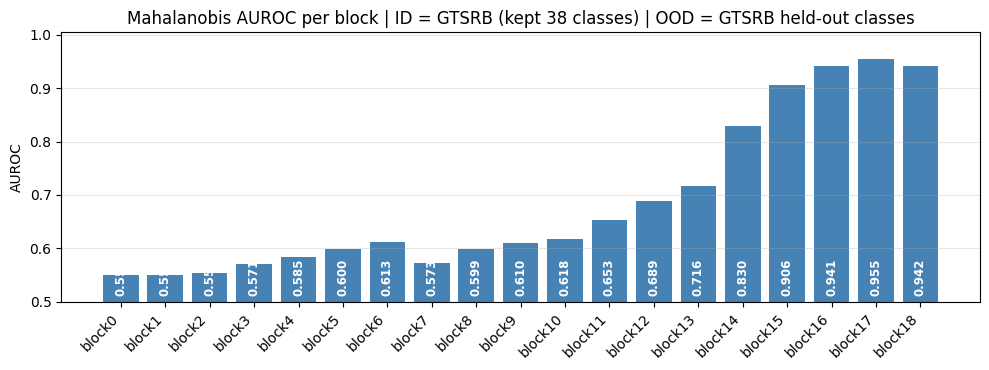

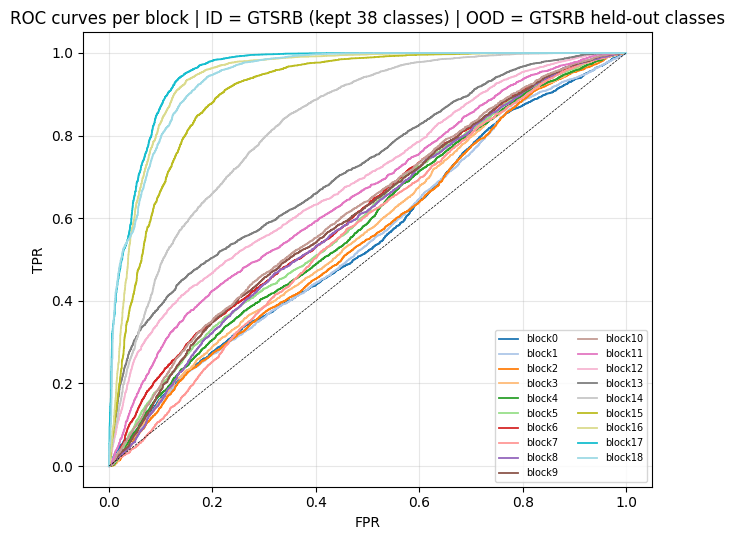

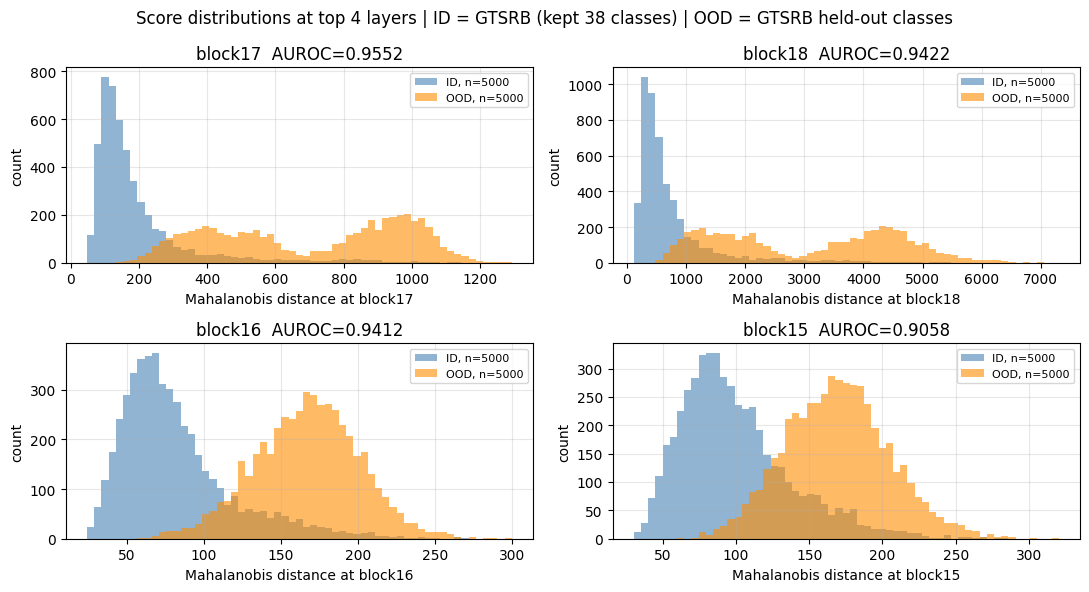

In [24]:
near_result = analyze_ood_source(holdout_ood_ds, "gtsrb_holdout", "GTSRB held-out classes")

  load  fgsm_kept.npz

ID = GTSRB (kept 38 classes) | OOD = GTSRB held-out
method                          AUROC   TNR@95   DetAcc
best single (block17)         0.9552   0.6588   0.9018
mean_z (stage)                0.7732   0.3432   0.6942
mean_z (all)                  0.7720   0.2796   0.6866
uniform_sum (stage)           0.7732   0.3432   0.6942
logreg_fgsm (all)             0.8698   0.2952   0.8104


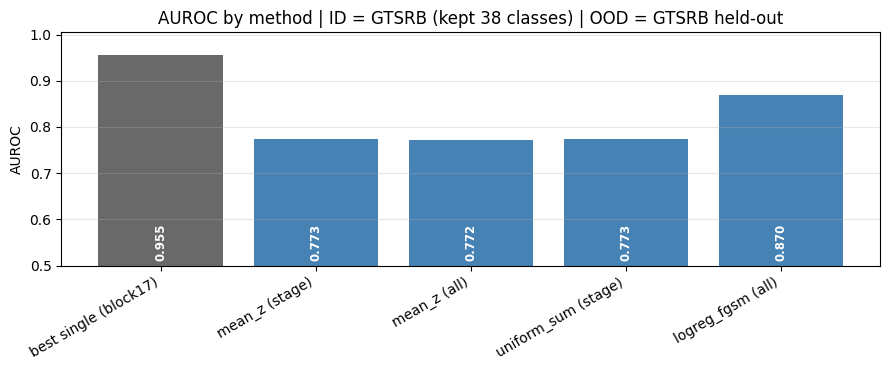

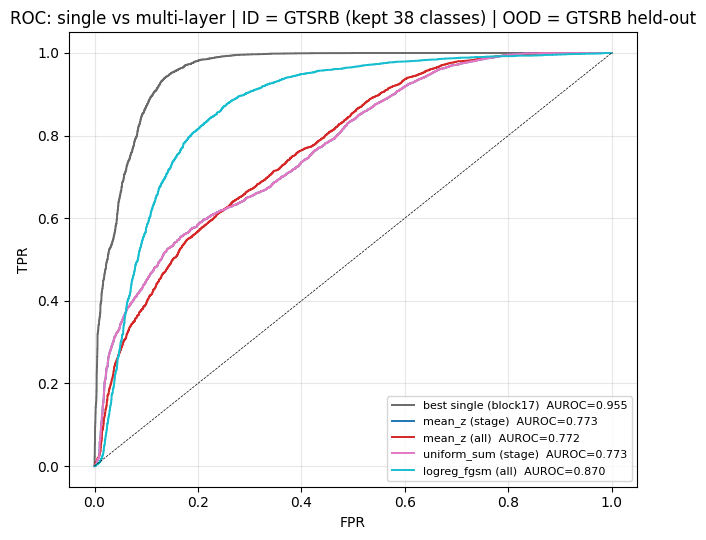

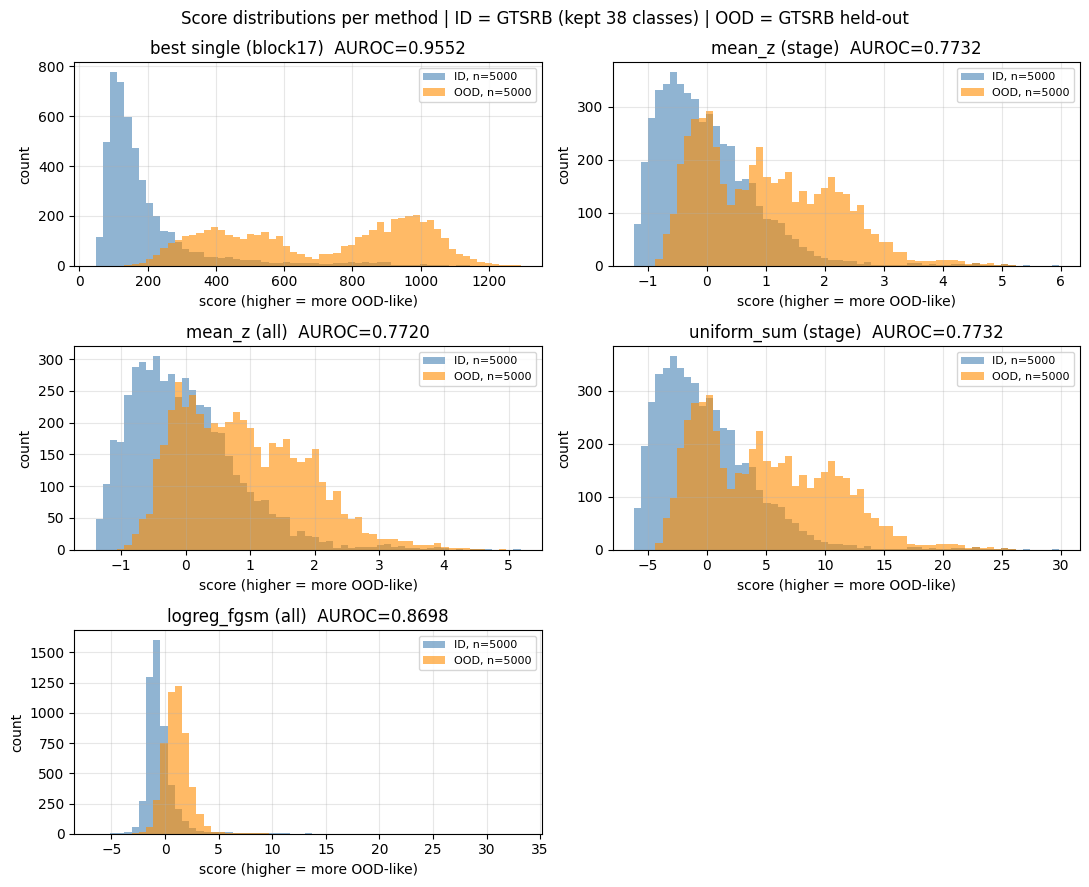

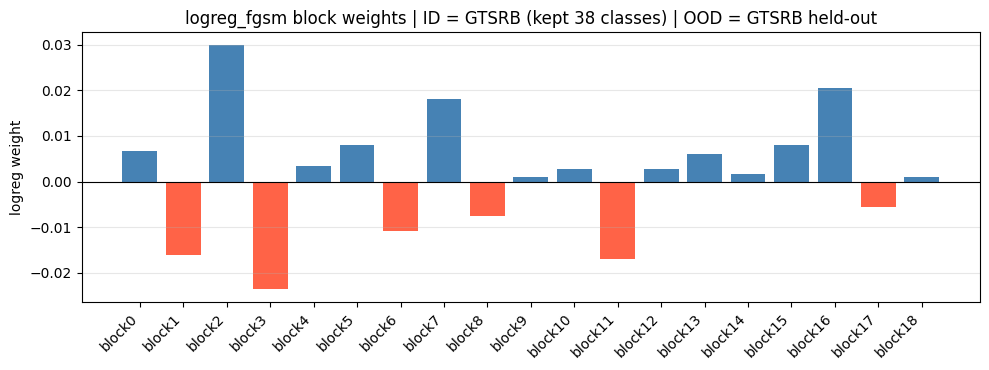

{'rows': [('best single (block17)', 0.95521364, 0.6588, 0.9017999999999999),
  ('mean_z (stage)', 0.77319428, 0.3432, 0.6942),
  ('mean_z (all)', 0.7720492800000001, 0.2796, 0.6866),
  ('uniform_sum (stage)', 0.77319428, 0.3432, 0.6942),
  ('logreg_fgsm (all)', 0.86976524, 0.2952, 0.8104)],
 'scores': [('best single (block17)',
   array([409.9439158 , 128.40833532, 256.0899328 , ...,  97.18983483,
          131.02370845, 104.95915108]),
   array([ 426.08260839,  482.98937869,  824.04237185, ..., 1015.78580401,
           871.37053584, 1020.19011222]),
   0.95521364),
  ('mean_z (stage)',
   array([ 0.30663039, -0.2133399 ,  0.28854929, ..., -1.16774049,
           1.16199492, -0.22319097]),
   array([ 2.17246789, -0.41496412,  1.15156902, ...,  1.41963218,
           0.937182  ,  0.81113955]),
   0.77319428),
  ('mean_z (all)',
   array([ 0.29953331, -0.27368858,  0.42413476, ..., -1.30274135,
           1.46349879, -0.34486562]),
   array([ 1.64641911, -0.48465216,  0.77971261, ...,  

In [25]:
analyze_combined(near_result, "GTSRB held-out", tag="kept")

  load  fgsm_kept.npz

ID = GTSRB (kept 38 classes) | OOD = GTSRB held-out
method                          AUROC   TNR@95   DetAcc
best single (block17)         0.9552   0.6588   0.9018
mean_z (stage)                0.7732   0.3432   0.6942
mean_z (all)                  0.7720   0.2796   0.6866
uniform_sum (stage)           0.7732   0.3432   0.6942
logreg_fgsm (all)             0.8698   0.2952   0.8104
mean_z (custom, 2)            0.9502   0.6236   0.8894
logreg_fgsm (custom, 2)       0.9517   0.6404   0.8926


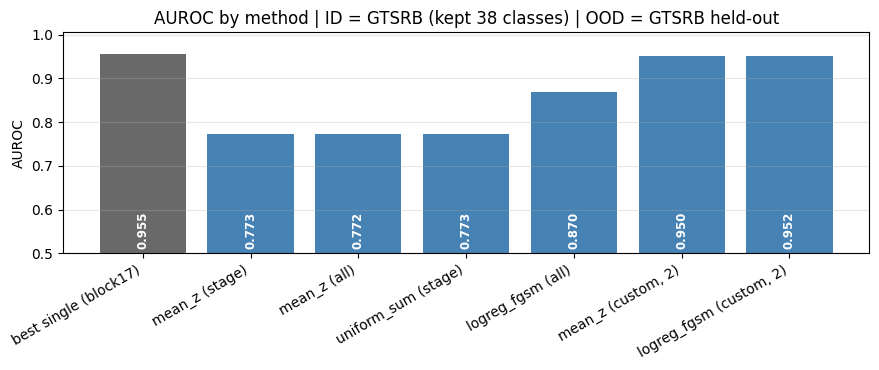

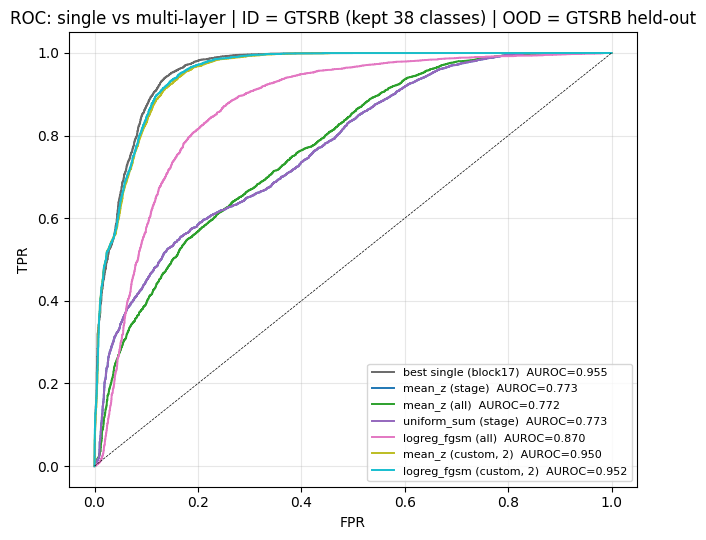

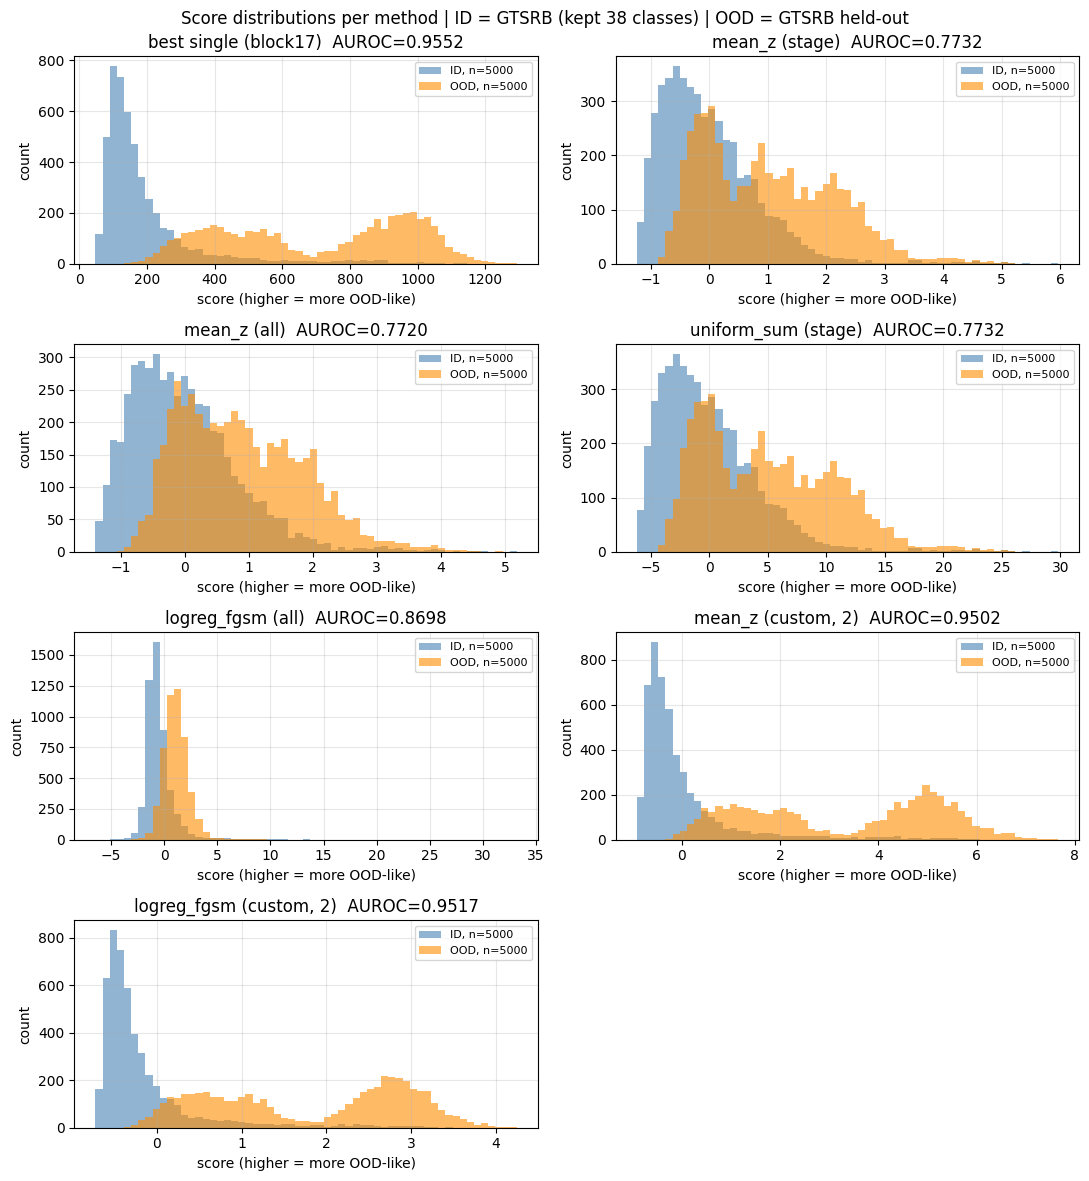

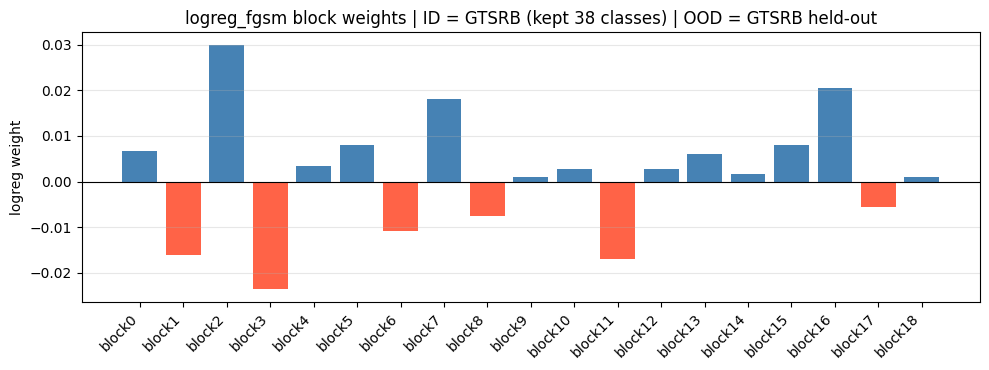

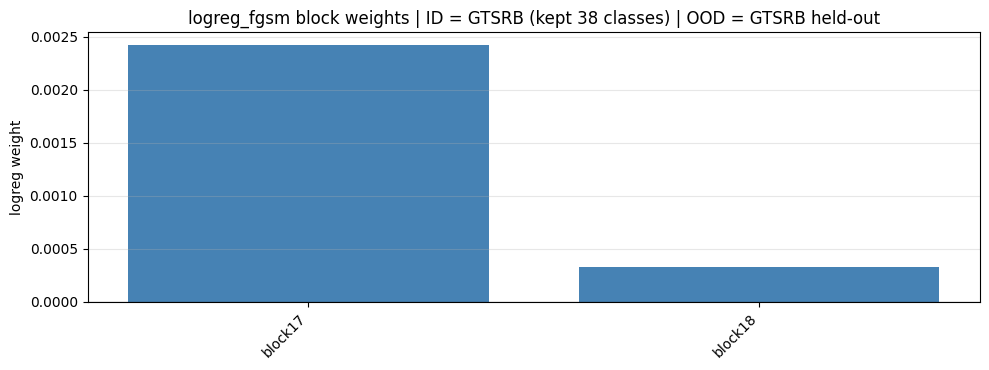

{'rows': [('best single (block17)', 0.95521364, 0.6588, 0.9017999999999999),
  ('mean_z (stage)', 0.77319428, 0.3432, 0.6942),
  ('mean_z (all)', 0.7720492800000001, 0.2796, 0.6866),
  ('uniform_sum (stage)', 0.77319428, 0.3432, 0.6942),
  ('logreg_fgsm (all)', 0.86976524, 0.2952, 0.8104),
  ('mean_z (custom, 2)', 0.95015128, 0.6236, 0.8894),
  ('logreg_fgsm (custom, 2)', 0.95171404, 0.6404, 0.8926000000000001)],
 'scores': [('best single (block17)',
   array([409.9439158 , 128.40833532, 256.0899328 , ...,  97.18983483,
          131.02370845, 104.95915108]),
   array([ 426.08260839,  482.98937869,  824.04237185, ..., 1015.78580401,
           871.37053584, 1020.19011222]),
   0.95521364),
  ('mean_z (stage)',
   array([ 0.30663039, -0.2133399 ,  0.28854929, ..., -1.16774049,
           1.16199492, -0.22319097]),
   array([ 2.17246789, -0.41496412,  1.15156902, ...,  1.41963218,
           0.937182  ,  0.81113955]),
   0.77319428),
  ('mean_z (all)',
   array([ 0.29953331, -0.27368858,

In [26]:
top2 = sorted(LAYER_NAMES, key=lambda n: near_result["per_layer"][n]["auroc"], reverse=True)[:2]
analyze_combined(near_result, "GTSRB held-out", tag="kept", custom_layers=top2)

## 5. Oxford-IIIT Pet as ID

First run notebook_oxford_indomain.ipynb to obtain model. Same pipeline as Sections 2-4, but with a different ID dataset: 37-breed cat/dog classifier (`mobilenetv2_oxford_best.pth`). OOD is Tiny-ImageNet with cat/dog wnids excluded (otherwise the OOD pool semantically overlaps with the ID classes). All Oxford-specific caches are prefixed with `oxford_`.

### 5.1 Load Oxford-IIIT Pet model

In [27]:
OXFORD_CKPT_PATH = os.path.join(CKPT_DIR, "mobilenetv2_oxford_best.pth")
N_OXFORD = 37

from torchvision.datasets import OxfordIIITPet as _OxfordIIITPet
print("--> Oxford trainval"); _OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category", download=True)
print("--> Oxford test");     _OxfordIIITPet(root=DATA_DIR, split="test", target_types="category", download=True)

ckpt_oxford = torch.load(OXFORD_CKPT_PATH, map_location=DEVICE, weights_only=True)
model = build_model(pretrained=False, num_classes=N_OXFORD)
model.load_state_dict(ckpt_oxford["model_state_dict"])
model = model.to(DEVICE).eval()
hooks = FeatureHooks(model, LAYERS, pooling=M_DISTANCE_POOLING)
oxford_train_idx = np.asarray(ckpt_oxford["train_idx"])
print(f"loaded Oxford model  epoch={ckpt_oxford['epoch']}  val_acc={ckpt_oxford['val_acc']:.4f}  N_OXFORD={N_OXFORD}")

oxford_train_eval = _OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category", transform=eval_tf)
oxford_test = _OxfordIIITPet(root=DATA_DIR, split="test", target_types="category", transform=eval_tf)

oxford_test_acc_path = os.path.join(CACHE_DIR, "oxford_test_acc.json")
if os.path.exists(oxford_test_acc_path):
    oxford_test_acc = json.load(open(oxford_test_acc_path))["test_acc"]
else:
    oxford_test_acc = accuracy(DataLoader(oxford_test, batch_size=128, num_workers=0))
    with open(oxford_test_acc_path, "w") as f:
        json.dump({"test_acc": oxford_test_acc}, f)

print(f"Oxford model-val top-1 (random 10% of train, leaky): {ckpt_oxford['val_acc']:.4f}")
print(f"Oxford official test  top-1: {oxford_test_acc:.4f}")

--> Oxford trainval
--> Oxford test
loaded Oxford model  epoch=8  val_acc=0.9024  N_OXFORD=37
Oxford model-val top-1 (random 10% of train, leaky): 0.9024
Oxford official test  top-1: 0.8525


### 5.2 Fit Gaussians on Oxford features

In [28]:
oxford_fit_ds = Subset(oxford_train_eval, oxford_train_idx)

EVAL_ID_NAME = "Oxford-IIIT Pet"
rng = np.random.default_rng(1)
perm_oxford = rng.permutation(len(oxford_test))[:N_ID_VAL + N_ID_TEST]
id_val_ds = Subset(oxford_test, perm_oxford[:N_ID_VAL])
oxford_id_test_ds = Subset(oxford_test, perm_oxford[N_ID_VAL:])

print("extracting features ...")
oxford_fit_out = extract_cached("oxford_fit", oxford_fit_ds, labels_too=True)
oxford_id_test_out = extract_cached("oxford_id_test", oxford_id_test_ds, also_logits=True, labels_too=True)

gaussians = {n: fit_gaussian(oxford_fit_out["features"][n], oxford_fit_out["labels"], N_OXFORD)
             for n in LAYER_NAMES}
md_id_test = {n: score_layer(n, oxford_id_test_out["features"][n]) for n in LAYER_NAMES}

# Aliases used by the per-sample diagnostics below
fit_out = oxford_fit_out
fit_labels = oxford_fit_out["labels"]
print("Gaussians refit on Oxford; ID-test reference refreshed.")

extracting features ...
  load  oxford_fit.npz
  load  oxford_id_test.npz
Gaussians refit on Oxford; ID-test reference refreshed.


### 5.3 Tiny-ImageNet OOD (semantically in-domain classes excluded)

Cat/dog wnids are dropped from the OOD pool. Otherwise the closest OOD images would actually be the same breeds the model was trained to recognize.

Tiny-ImageNet (Oxford OOD pool): 96000 images  (excluded 4000 from 8 wnids)
  load  ood_test_oxford_tiny_imagenet.npz
ID = Oxford-IIIT Pet | OOD = Tiny-ImageNet (Oxford ID, dog/cat wnids excluded)
layer         AUROC   TNR@95   DetAcc
block0      0.5852   0.1522   0.5749
block1      0.4943   0.0838   0.5195
block2      0.5400   0.0498   0.5422
block3      0.6119   0.0590   0.5944
block4      0.5724   0.0350   0.5716
block5      0.5806   0.0448   0.5698
block6      0.6032   0.0552   0.5807
block7      0.8416   0.2606   0.7776
block8      0.8978   0.4396   0.8331
block9      0.9287   0.5880   0.8627
block10     0.9660   0.8090   0.9172
block11     0.9008   0.4736   0.8334
block12     0.8567   0.3410   0.7897
block13     0.8222   0.2898   0.7528
block14     0.9951   0.9892   0.9730
block15     0.9957   0.9944   0.9759
block16     0.9946   0.9906   0.9731
block17     0.9977   0.9972   0.9822
block18     0.9600   0.7660   0.8986


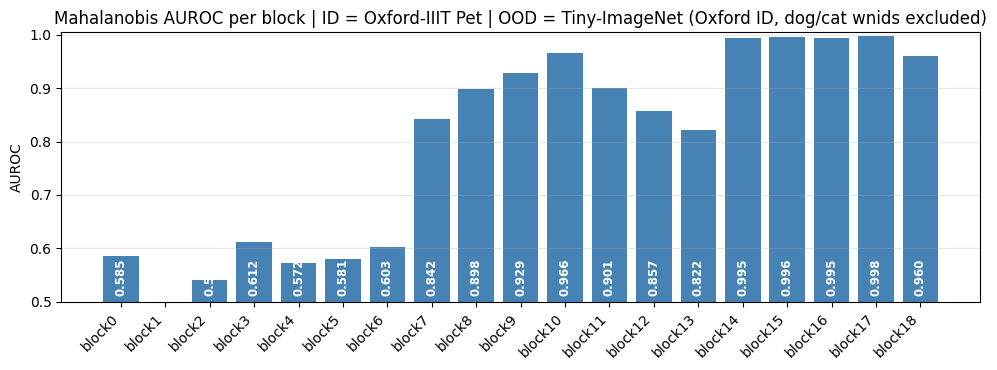

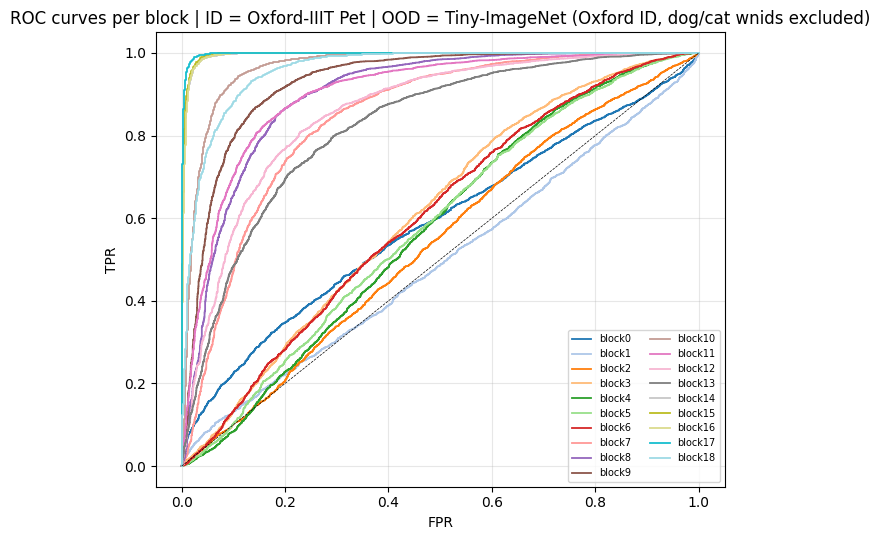

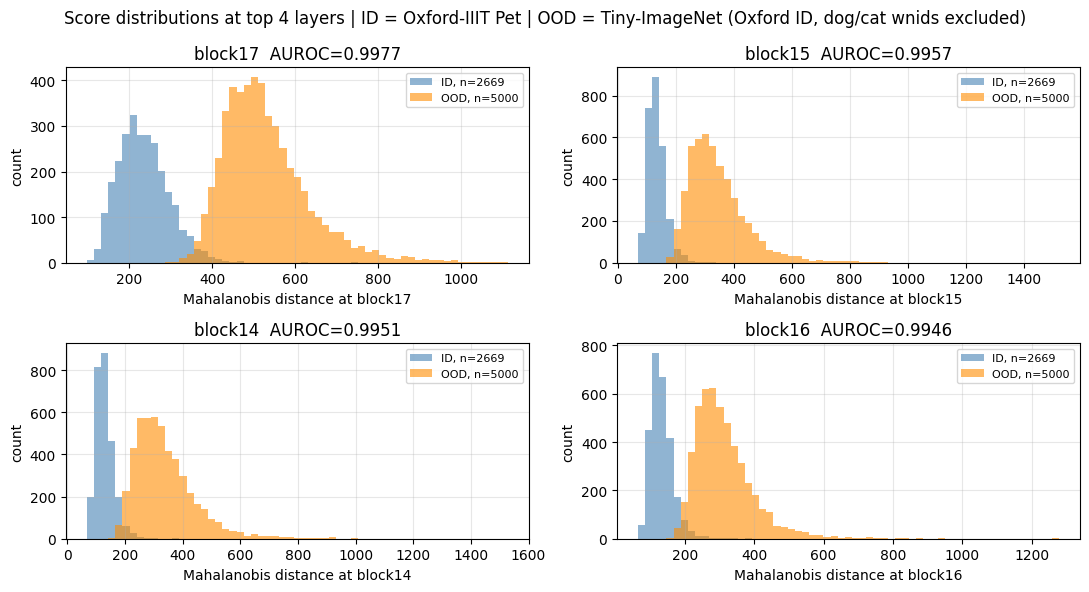

In [29]:
# Cat/dog wnids that overlap with Oxford-IIIT Pet ID classes
EXCLUDED_TINY_WNIDS = {
    "n02106662", # German shepherd
    "n02123045", # tabby
    "n02124075", # Egyptian cat
    "n02099601", # golden retriever
    "n02085620", # Chihuahua
    "n02113799", # standard poodle
    "n02099712", # Labrador retriever
    "n02094433", # Yorkshire terrier
}

tin_train_root = os.path.join(download_tiny_imagenet(), "train")
tin_oxford_base = TinyImageNetFlat(tin_train_root, transform=eval_tf, exclude_wnids=EXCLUDED_TINY_WNIDS)
excluded_count = len(TinyImageNetFlat(tin_train_root, transform=eval_tf)) - len(tin_oxford_base)
print(f"Tiny-ImageNet (Oxford OOD pool): {len(tin_oxford_base)} images  "
      f"(excluded {excluded_count} from {len(EXCLUDED_TINY_WNIDS)} wnids)")

tin_oxford_ds = OODWrapper(tin_oxford_base, n=N_OOD_TEST, seed=0)
oxford_tin_result = analyze_ood_source(tin_oxford_ds, "oxford_tiny_imagenet",
                                       "Tiny-ImageNet (Oxford ID, dog/cat wnids excluded)")

  load  fgsm_oxford.npz

ID = Oxford-IIIT Pet | OOD = Tiny-ImageNet (Oxford ID)
method                          AUROC   TNR@95   DetAcc
best single (block17)         0.9977   0.9972   0.9822
mean_z (stage)                0.8669   0.3178   0.7991
mean_z (all)                  0.9769   0.8838   0.9330
uniform_sum (stage)           0.8669   0.3178   0.7991
logreg_fgsm (all)             0.9971   0.9956   0.9791


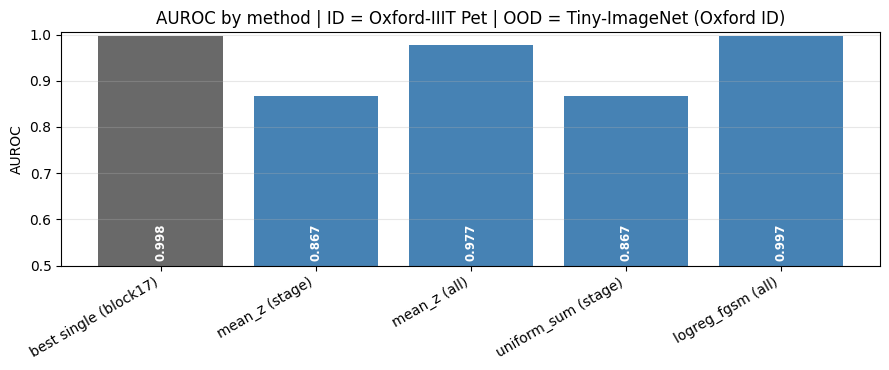

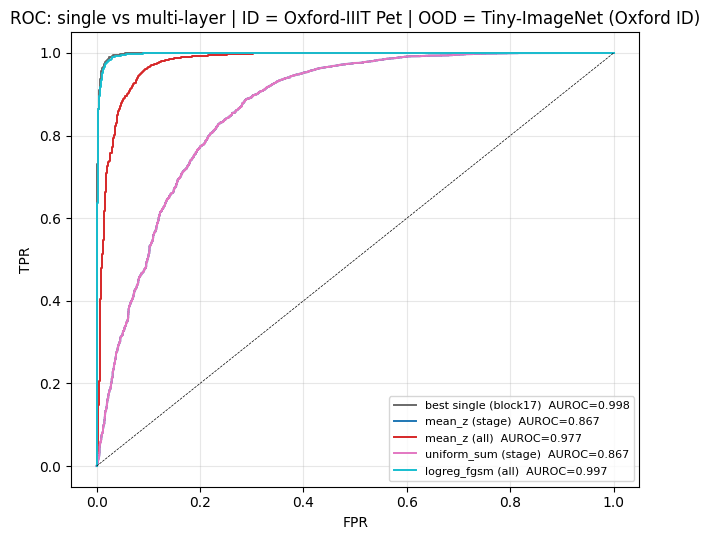

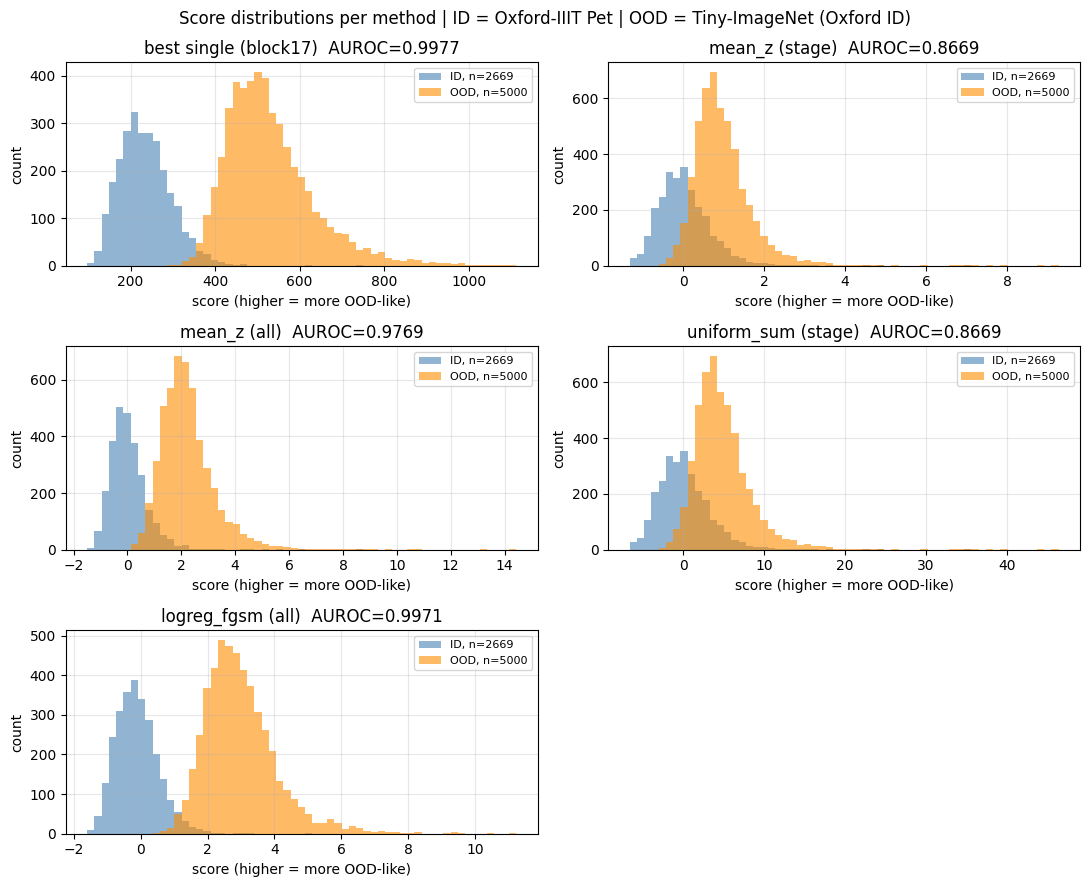

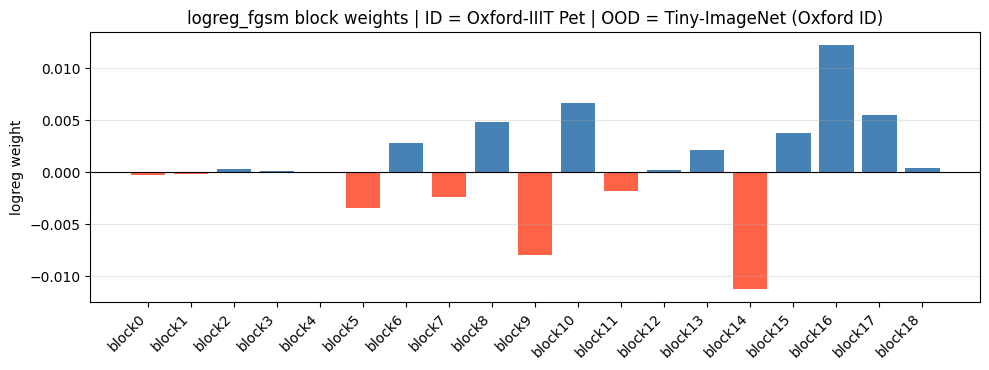

{'rows': [('best single (block17)',
   0.9976638441363807,
   0.9972,
   0.9822484825777444),
  ('mean_z (stage)', 0.8669143499437991, 0.3178, 0.7991018733608093),
  ('mean_z (all)', 0.9769321094042712, 0.8838, 0.9329913076058449),
  ('uniform_sum (stage)', 0.8669143499437991, 0.3178, 0.7991018733608093),
  ('logreg_fgsm (all)', 0.997073585612589, 0.9956, 0.9790851629823905)],
 'scores': [('best single (block17)',
   array([140.87966941, 210.53925435, 270.85594621, ..., 259.14369293,
          282.22795837, 164.0655549 ]),
   array([498.34322741, 480.27929082, 628.10247127, ..., 400.41736666,
          776.56330629, 638.16358664]),
   0.9976638441363807),
  ('mean_z (stage)',
   array([-0.55344446, -0.06711562, -0.6425842 , ..., -0.05248612,
           0.63982342, -0.43639434]),
   array([ 0.79902442, -0.37264549,  1.67221634, ...,  0.93471928,
           1.77684994,  1.53543031]),
   0.8669143499437991),
  ('mean_z (all)',
   array([-0.50094415,  0.1171914 , -0.54791266, ..., -0.00801

In [30]:
analyze_combined(oxford_tin_result, "Tiny-ImageNet (Oxford ID)", tag="oxford")

### 5.4 Per-sample OOD diagnostics

In [31]:
from collections import Counter
from IPython.display import display

# Load Tiny-ImageNet class descriptions
tiny_root = os.path.join(DATA_DIR, "tiny-imagenet-200")
wnids_path = os.path.join(tiny_root, "wnids.txt")
words_path = os.path.join(tiny_root, "words.txt")

def load_tiny_imagenet_descriptions(wnids_file, words_file):
    wnids = [line.strip() for line in open(wnids_file, encoding="utf-8") if line.strip()]
    descriptions = {}
    with open(words_file, encoding="utf-8") as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line: continue
            if "\t" in line:
                wnid, description = line.split("\t", 1)
            else:
                parts = line.split(None, 1)
                wnid = parts[0]
                description = parts[1] if len(parts) > 1 else ""
            descriptions[wnid] = description
    return wnids, descriptions

wnids, wnid_descriptions = load_tiny_imagenet_descriptions(wnids_path, words_path)

# Identify the best-performing layer and analyze false-in-domain Tiny-ImageNet classes
best_layer = max(LAYER_NAMES, key=lambda name: oxford_tin_result["per_layer"][name]["auroc"])
id_threshold = np.quantile(md_id_test[best_layer], 0.95)
ood_scores = oxford_tin_result["md_ood"][best_layer]
false_in_mask = ood_scores < id_threshold

sample_paths = [tin_oxford_ds.base.paths[int(i)] for i in tin_oxford_ds.idx]
sample_wnids = [os.path.basename(os.path.dirname(os.path.dirname(p))) for p in sample_paths]
failed_counts = Counter(w for w, m in zip(sample_wnids, false_in_mask) if m)

failed_df = pd.DataFrame(
    [(w, n, wnid_descriptions.get(w, "")) for w, n in failed_counts.items()],
    columns=["wnid", "false_in_domain_count", "description"],
).sort_values(["false_in_domain_count", "wnid"], ascending=[False, True]).reset_index(drop=True)

print(f"Best AUROC layer: {best_layer}")
print(f"ID threshold (95th percentile): {id_threshold:.4f}")
print(f"False in-domain Tiny-ImageNet samples: {int(false_in_mask.sum())} / {len(false_in_mask)}")
print(f"Distinct Tiny-ImageNet classes with false in-domain samples: {len(failed_df)}")
display(failed_df)

Best AUROC layer: block17
ID threshold (95th percentile): 339.7918
False in-domain Tiny-ImageNet samples: 14 / 5000
Distinct Tiny-ImageNet classes with false in-domain samples: 13


,wnid,false_in_domain_count,description
0,n02437312,2,"Arabian camel, dromedary, Camelus dromedarius"
1,n02002724,1,"black stork, Ciconia nigra"
2,n02058221,1,"albatross, mollymawk"
3,n02132136,1,"brown bear, bruin, Ursus arctos"
4,n02403003,1,ox
5,n02793495,1,barn
6,n02837789,1,"bikini, two-piece"
7,n02950826,1,cannon
8,n02963159,1,cardigan
9,n03126707,1,crane


  load  ood_test_oxford_tiny_imagenet.npz
Using layer: block17
Most ID-like OOD samples (top-6)


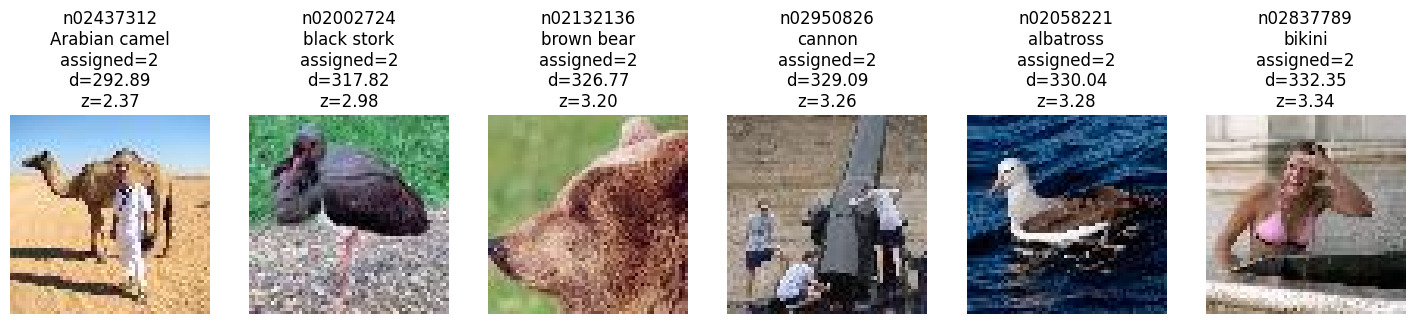

Most outlying assigned OOD samples (top-6)


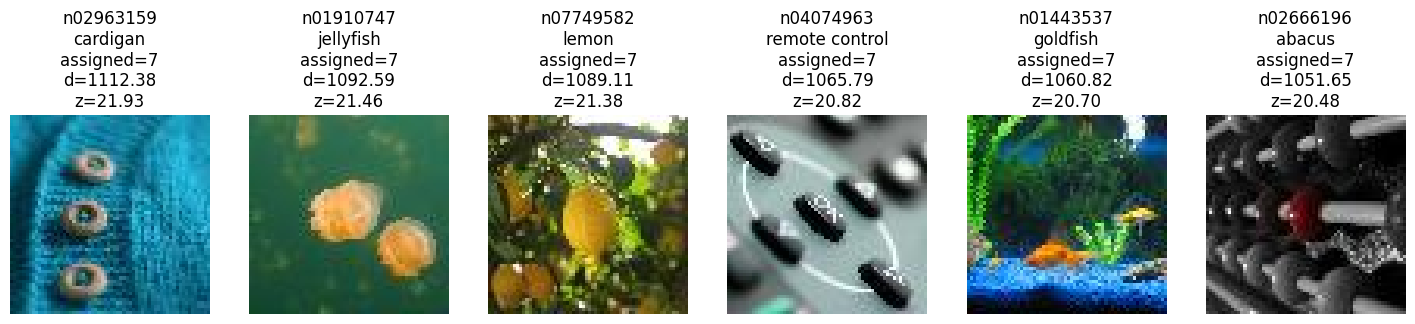

Highest z-score OOD samples (top-6)


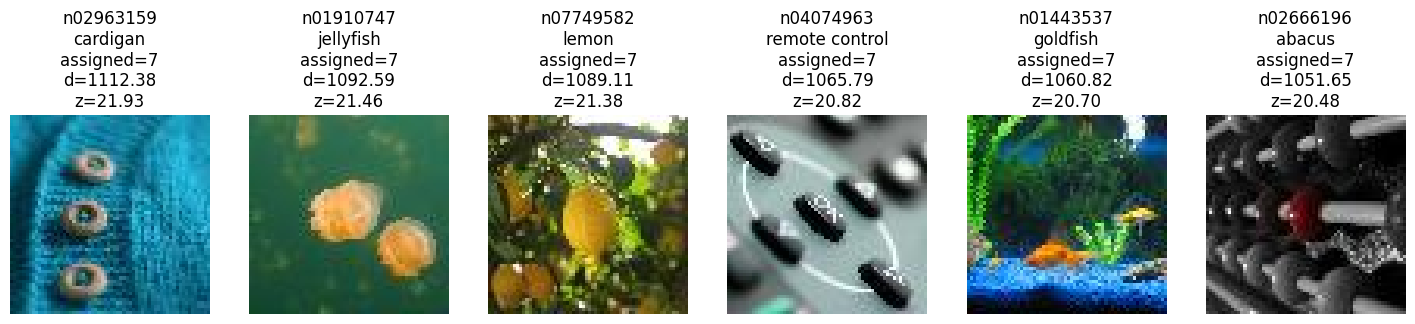

Saved per-sample report to cache\oxford_tiny_imagenet_ood_per_sample_block17.csv


In [32]:
# Per-sample diagnostics: nearest-class, distance, z-score relative to assigned class
layer = best_layer
means, prec = gaussians[layer]

ood_out = extract_cached(f"ood_test_oxford_tiny_imagenet", tin_oxford_ds, also_logits=False)
ood_feats = ood_out["features"][layer].astype(np.float64)
id_feats = fit_out["features"][layer].astype(np.float64)
id_labels = fit_labels

P = prec.astype(np.float64)
Px = ood_feats @ P
quad_x = np.einsum("nd,nd->n", Px, ood_feats)
Pmu = means @ P
quad_mu = np.einsum("cd,cd->c", Pmu, means)
cross = Px @ means.T
all_dists = quad_x[:, None] + quad_mu[None, :] - 2.0 * cross

nearest = all_dists.argmin(axis=1)
min_dist = all_dists.min(axis=1)

Px_id = id_feats @ P
quad_x_id = np.einsum("nd,nd->n", Px_id, id_feats)
cross_id = Px_id @ means.T
all_dists_id = quad_x_id[:, None] + quad_mu[None, :] - 2.0 * cross_id

class_stats = {}
for c in range(means.shape[0]):
    sel = (id_labels == c)
    if sel.sum() == 0:
        class_stats[c] = (0.0, 1.0); continue
    dists_c = all_dists_id[sel, c]
    class_stats[c] = (float(dists_c.mean()), float(dists_c.std()) if dists_c.std() > 0 else 1e-6)

rows = []
for i, path in enumerate(sample_paths):
    c = int(nearest[i])
    d = float(min_dist[i])
    mu, sigma = class_stats.get(c, (0.0, 1.0))
    rows.append({"idx": i, "path": path, "wnid": sample_wnids[i],
                 "assigned_class": c, "distance": d, "z_score": (d - mu) / (sigma + 1e-12),
                 "description": wnid_descriptions.get(sample_wnids[i], "")})
df = pd.DataFrame(rows)

print(f"Using layer: {layer}")

def truncate_desc(d): return d.split(",", 1)[0].strip() if d else ""

def show_samples(subdf, title):
    print(title)
    n = min(6, len(subdf))
    fig, axs = plt.subplots(1, n, figsize=(3*n, 3))
    for ax, (_, r) in zip(axs, subdf.iterrows()):
        ax.imshow(Image.open(r.path).convert("RGB"))
        ax.set_title(f"{r.wnid}\n{truncate_desc(r.description or '')}\n"
                     f"assigned={r.assigned_class}\nd={r.distance:.2f}\nz={r.z_score:.2f}")
        ax.axis("off")
    plt.show()

show_samples(df.sort_values("distance").head(6), "Most ID-like OOD samples (top-6)")
show_samples(df.sort_values("distance", ascending=False).head(6), "Most outlying assigned OOD samples (top-6)")
show_samples(df.sort_values("z_score", ascending=False).head(6), "Highest z-score OOD samples (top-6)")

out_csv = os.path.join(CACHE_DIR, f"oxford_tiny_imagenet_ood_per_sample_{layer}.csv")
df.to_csv(out_csv, index=False)
print(f"Saved per-sample report to {out_csv}")